# 엑셀 파일을 분석하기 위해 필요한 라이브러리

In [1]:
!pip install openpyxl

### 한글을 plot에 표시하기 위해 필요한 사전 작업

In [2]:
import platform 
import matplotlib.pyplot as plt 

# Mac인 경우 한글 폰트 설정
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우용
else:
    plt.rc('font', family='DejaVu Sans')    # 리눅스 기본
# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [66]:
import pandas as pd

# 엑셀 읽기 (2줄 헤더)
df = pd.read_excel("인구증가율.xlsx", engine="openpyxl", header=[0, 1])

df.head(len(df))

행정구역별                   2015                               \
      행정구역별 인구증가율{(A-B)÷B}×100 (%) 당해년 총인구(A) (명) 전년 총인구(B) (명)   
0        전국                   0.48       52672425      52419447   
1     서울특별시                  -0.70       10297138      10369593   
2     부산광역시                  -0.11        3553768       3557716   
3     대구광역시                  -0.18        2513970       2518467   
4     인천광역시                   0.86        2983484       2957931   
5     광주광역시                  -0.15        1490654       1492948   
6     대전광역시                  -0.79        1535191       1547467   
7     울산광역시                   0.63        1199717       1192262   
8   세종특별자치시                  34.94         214365        158855   
9       경기도                   1.43       12892271      12709996   
10  강원특별자치도                   0.37        1564615       1558885   
11     충청북도                   0.43        1616589       1609633   
12     충청남도                   0.82        2134232       2116830   
13  전북특별자치도                  -0.04        1895905       1896646   
14     전라남도                   0.29        1939562       1934034   
15     경상북도                   0.15        2752591       2748599   
16     경상남도                   0.55        3447018       3428035   
17  제주특별자치도                   3.19         641355        621550   

                     2016                                                2017  \
   인구증가율{(A-B)÷B}×100 (%) 당해년 총인구(A) (명) 전년 총인구(B) (명) 인구증가율{(A-B)÷B}×100 (%)   
0                    0.35       52857893      52672425                   0.17   
1                   -0.90       10204057      10297138                  -0.78   
2                   -0.38        3540369       3553768                  -0.76   
3                   -0.12        2511050       2513970                  -0.37   
4                    0.63        3002172       2983484                   0.30   
5                   -0.10        1489134       1490654                  -0.27   
6                   -0.25        1531405       1535191                  -0.77   
7                   -0.33        1195761       1199717                  -0.85   
8                   15.13         246793        214365                  15.17   
9                    1.54       13090703      12892271                   1.26   
10                   0.13        1566639       1564615                   0.03   
11                   0.65        1627124       1616589                   0.24   
12                   1.07        2157080       2134232                   1.11   
13                  -0.20        1892111       1895905                  -0.47   
14                  -0.20        1935664       1939562                  -0.41   
15                  -0.03        2751749       2752591                  -0.24   
16                   0.23        3454892       3447018                   0.02   
17                   3.09         661190        641355                   2.66   

                                 ...          2021                   2022  \
   당해년 총인구(A) (명) 전년 총인구(B) (명)  ... 전년 총인구(B) (명) 인구증가율{(A-B)÷B}×100 (%)   
0        52950306      52857893  ...      52974563                  -0.20   
1        10124579      10204057  ...       9911088                  -0.70   
2         3513490       3540369  ...       3432312                  -0.86   
3         2501673       2511050  ...       2446144                  -0.80   
4         3011138       3002172  ...       3010476                   0.81   
5         1485049       1489134  ...       1471385                  -0.58   
6         1519658       1531405  ...       1480777                  -0.20   
7         1185645       1195761  ...       1153901                  -0.82   
8          284225        246793  ...        360907                   3.22   
9        13255523      13090703  ...      13807158                   0.33   
10        1567091       1566639  ...       1560172                   0.07   
11        1631088       1627124  ...       

In [70]:
import dataframe_image as dfi

# max_rows와 max_cols 숫자를 지정해주면 나머지는 '...'으로 자동 생략됩니다.
dfi.export(
    df,  # 자르지 않은 원본 데이터프레임을 그대로 넣으세요
    "./image_data_structure.png",
    max_rows=12,   # 위/아래 행을 6개 정도만 남기고 생략
    max_cols=7,   # 좌/우 열을 6개 정도만 남기고 생략
    table_conversion="matplotlib"  # 브라우저 엔진 에러 방지용 옵션
)

print("✅ 생략 기호(...)가 포함된 요약 표 이미지 저장 완료!")

✅ 생략 기호(...)가 포함된 요약 표 이미지 저장 완료!


In [4]:
import numpy as np
import re

# 인구증가율 엑셀 다시 읽기
df = pd.read_excel("인구증가율.xlsx", engine="openpyxl", header=[0, 1])

# 결측치 처리
df.replace(['-', '--', '…'], np.nan, inplace=True)

# 연도 이름 정리 함수
def clean_year(x):
    text = str(x)
    match = re.search(r'(19\d{2}|20\d{2})', text)
    if match:
        return match.group(1)
    return text

# 행정구역 컬럼 찾기
region_col = [
    col for col in df.columns
    if ('행정구역' in str(col[0])) or ('시도' in str(col[0])) or ('시군구' in str(col[0]))
][0]

# 인구증가율 컬럼 찾기
pop_cols = [
    col for col in df.columns
    if ('인구증가율' in str(col[0])) or ('인구증가율' in str(col[1]))
]

# 필요한 열만 추출
df_pop = df[[region_col] + pop_cols].copy()

# 열 이름 단순화
df_pop.columns = ['지역'] + [clean_year(col[0]) for col in pop_cols]

# 숫자형으로 변환
for col in df_pop.columns[1:]:
    df_pop[col] = pd.to_numeric(df_pop[col], errors='coerce')

# 지역명 공백 제거
df_pop['지역'] = df_pop['지역'].astype(str).str.strip()

df_pop.head(len(df_pop))

,지역,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,전국,0.48,0.35,0.17,0.23,0.09,-0.28,-0.46,-0.20,0.09,0.06
1,서울특별시,-0.70,-0.90,-0.78,-0.74,-0.38,-1.00,-1.77,-0.70,-0.30,-0.43
2,부산광역시,-0.11,-0.38,-0.76,-0.75,-0.78,-0.80,-1.24,-0.86,-0.54,-0.60
3,대구광역시,-0.18,-0.12,-0.37,-0.47,-0.87,-0.89,-1.37,-0.80,0.63,-0.33
4,인천광역시,0.86,0.63,0.30,0.38,0.22,-0.62,0.14,0.81,1.29,1.03
5,광주광역시,-0.15,-0.10,-0.27,-0.20,-0.13,-0.60,-0.60,-0.58,-0.65,-0.66
6,대전광역시,-0.79,-0.25,-0.77,-0.76,-0.94,-0.88,-0.76,-0.20,-0.07,-0.01
7,울산광역시,0.63,-0.33,-0.85,-0.85,-0.61,-1.25,-1.34,-0.82,-0.16,-0.14
8,세종특별자치시,34.94,15.13,15.17,12.26,8.53,4.23,4.40,3.22,0.87,1.16
9,경기도,1.43,1.54,1.26,1.74,1.25,1.12,0.86,0.33,0.60,0.75


In [5]:
df_pop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   지역      18 non-null     object 
 1   2015    18 non-null     float64
 2   2016    18 non-null     float64
 3   2017    18 non-null     float64
 4   2018    18 non-null     float64
 5   2019    18 non-null     float64
 6   2020    18 non-null     float64
 7   2021    18 non-null     float64
 8   2022    18 non-null     float64
 9   2023    18 non-null     float64
 10  2024    18 non-null     float64
dtypes: float64(10), object(1)
memory usage: 1.7+ KB


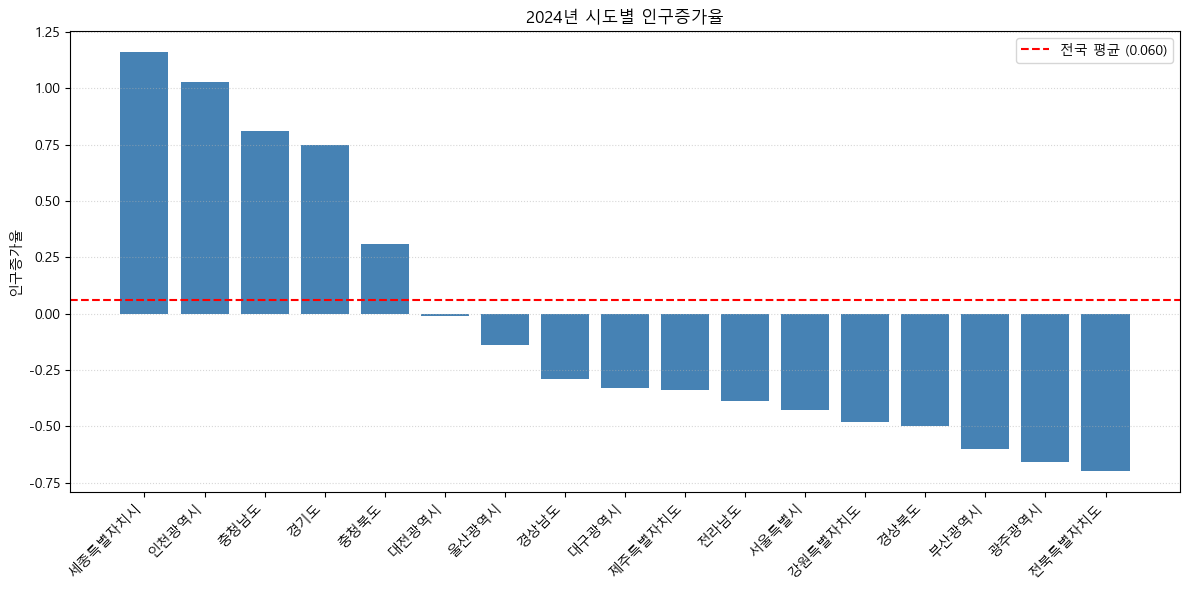

In [6]:
# 가장 최신 연도 자동 선택
year = df_pop.columns[-1]

# 특정 연도 데이터 정렬, 전국 제외
df_year = df_pop[df_pop['지역'] != '전국'][['지역', year]].copy()
df_year = df_year.sort_values(year, ascending=False)

# 전국 평균값 따로 추출
national_avg = df_pop[df_pop['지역'] == '전국'][year].values[0]

# 시각화
plt.figure(figsize=(12, 6))
plt.bar(df_year['지역'], df_year[year], color='steelblue')

# 전국 평균선 추가
plt.axhline(
    y=national_avg,
    color='red',
    linestyle='--',
    label=f'전국 평균 ({national_avg:.3f})'
)

plt.title(f'{year}년 시도별 인구증가율')
plt.ylabel('인구증가율')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

In [7]:
seoul = df_pop[df_pop['지역'] == '서울특별시'].iloc[0, 1:]
jeonnam = df_pop[df_pop['지역'] == '전라남도'].iloc[0, 1:]

# 열 이름을 정수형으로 변환
seoul.index = seoul.index.astype(int)
jeonnam.index = jeonnam.index.astype(int)

# 값도 수치형으로 변환
seoul = seoul.astype(float)
jeonnam = jeonnam.astype(float)

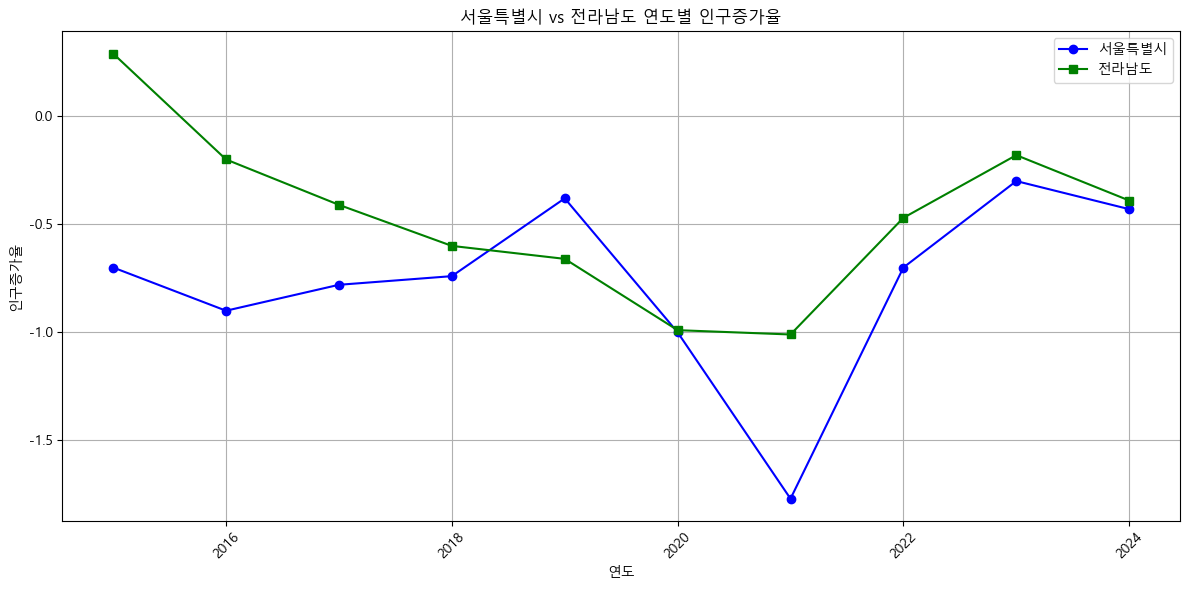

In [8]:
# x축 연도
years = seoul.index

# 시각화
plt.figure(figsize=(12, 6))
plt.plot(years, seoul, label='서울특별시', color='blue', marker='o')
plt.plot(years, jeonnam, label='전라남도', color='green', marker='s')

plt.title('서울특별시 vs 전라남도 연도별 인구증가율')
plt.xlabel('연도')
plt.ylabel('인구증가율')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 인구 증가율과 보육시설과의 상관관계 분석

In [9]:
# 엑셀 읽기 (2줄 헤더)
factor1 = pd.read_excel("보육시설.xlsx", engine="openpyxl", header=[0, 1])

factor1.head(len(factor1))

행정구역별                        2008                                  \
      행정구역별 유아 천명당 보육시설수(A÷B×1,000) (개) 보육시설(A) (개) 주민등록인구(0~5세)(B) (명)   
0        전국                          12       33499             2782972   
1     서울특별시                        10.7        5600              523287   
2     부산광역시                        10.5        1651              157882   
3     대구광역시                        11.1        1426              127920   
4     인천광역시                        10.7        1652              154506   
5     광주광역시                        12.6        1096               87243   
6     대전광역시                        14.7        1318               89887   
7     울산광역시                         9.1         609               67142   
8   세종특별자치시                           -           -                   -   
9       경기도                        13.2        9712              733284   
10  강원특별자치도                        11.3         885               78474   
11     충청북도                        11.1         950               85787   
12     충청남도                        11.5        1344              117283   
13  전북특별자치도                          15        1479               98863   
14     전라남도                        10.7        1054               98315   
15     경상북도                        12.3        1708              138585   
16     경상남도                        13.5        2539              188721   
17  제주특별자치도                        13.3         476               35793   

                          2009                                  \
   유아 천명당 보육시설수(A÷B×1,000) (개) 보육시설(A) (개) 주민등록인구(0~5세)(B) (명)   
0                           13       35550             2736537   
1                         11.1        5684              511746   
2                         10.8        1655              153636   
3                         12.1        1500              124359   
4                         11.6        1773              152192   
5                         13.4        1153               85754   
6                         16.2        1417               87627   
7                           10         660               66078   
8                            -           -                   -   
9                         14.4       10465              725746   
10                          12         926               76946   
11                        12.2        1037               84846   
12                        12.5        1470              117882   
13                        15.6        1506               96787   
14                        11.6        1114               95844   
15                        13.6        1827              134724   
16                        15.2        2861              187727   
17                        14.5         502               34643   

                          2010                                  ...  \
   유아 천명당 보육시설수(A÷B×1,000) (개) 보육시설(A) (개) 주민등록인구(0~5세)(B) (명)  ...   
0                         13.9       38021             2734976  ...   
1                         11.7        5870              502633  ...   
2                           11        1689              153080  ...   
3                         12.5        1544              123208  ...   
4                         12.2        1857              152329  ...   
5                         13.9        1192               85822  ...   
6                         17.6        1535               87180  ...   
7                         11.4         754               66090  ...   
8                            -           -                   -  ...   
9                         15.3       11273              734996  ...   
10                        14.3        1085               75851  ...   
11                          13        1112               85391  ...   
12                        14.1        1687              119513  ...   
13                        15.9        1531               96178  ...   
14                        11.9        1135      

In [10]:
factor1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 52 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   (행정구역별, 행정구역별)                       18 non-null     object 
 1   (2008, 유아 천명당 보육시설수(A÷B×1,000) (개))  18 non-null     object 
 2   (2008, 보육시설(A) (개))                  18 non-null     object 
 3   (2008, 주민등록인구(0~5세)(B) (명))          18 non-null     object 
 4   (2009, 유아 천명당 보육시설수(A÷B×1,000) (개))  18 non-null     object 
 5   (2009, 보육시설(A) (개))                  18 non-null     object 
 6   (2009, 주민등록인구(0~5세)(B) (명))          18 non-null     object 
 7   (2010, 유아 천명당 보육시설수(A÷B×1,000) (개))  18 non-null     object 
 8   (2010, 보육시설(A) (개))                  18 non-null     object 
 9   (2010, 주민등록인구(0~5세)(B) (명))          18 non-null     object 
 10  (2011, 유아 천명당 보육시설수(A÷B×1,000) (개))  18 non-null     object 
 11  (2011, 보육시설(A) (개))               

In [11]:
# 결측치 처리
factor1.replace(['-', '--', '…'], np.nan, inplace=True)

# 1. 행정구역 컬럼 추출
region_col = [
    col for col in factor1.columns
    if ('행정구역' in str(col[0])) or ('시도' in str(col[0]))
][0]

# 2. "유아 천명당 보육시설수" 열만 추출
facility_cols = [
    col for col in factor1.columns
    if '유아 천명당 보육시설수' in str(col[1])
]

# 3. 필요한 열만 추출
df_facility = factor1[[region_col] + facility_cols].copy()

# 4. 열 이름 단순화
df_facility.columns = ['지역'] + [clean_year(col[0]) for col in facility_cols]

# 5. 숫자형 변환
for col in df_facility.columns[1:]:
    df_facility[col] = pd.to_numeric(df_facility[col], errors='coerce')

# 6. 지역명 공백 제거
df_facility['지역'] = df_facility['지역'].astype(str).str.strip()

# 7. 확인
df_facility.head(len(df_facility))

C:\Users\parkg\AppData\Local\Temp\ipykernel_3008\1938960370.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  factor1.replace(['-', '--', '…'], np.nan, inplace=True)


,지역,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,전국,12.0,13.0,13.9,14.3,15.1,15.8,16.0,15.5,15.3,15.7,16.2,16.4,16.7,17.1,17.3,17.4,17.3
1,서울특별시,10.7,11.1,11.7,12.1,13.0,13.8,14.1,14.0,14.0,14.5,15.2,15.4,15.8,16.4,16.7,16.8,16.8
2,부산광역시,10.5,10.8,11.0,11.1,11.4,11.9,12.2,12.1,12.1,12.6,13.2,13.8,14.3,14.8,15.0,15.2,15.2
3,대구광역시,11.1,12.1,12.5,12.6,12.5,12.9,13.0,12.6,12.3,12.6,12.9,12.9,13.4,13.9,14.6,14.8,15.0
4,인천광역시,10.7,11.6,12.2,12.6,13.3,13.8,14.2,14.0,14.1,14.5,15.2,15.4,15.9,16.0,15.9,16.0,16.0
5,광주광역시,12.6,13.4,13.9,13.9,14.1,14.6,14.9,15.2,15.5,16.2,16.7,16.6,17.2,17.3,17.6,17.9,18.2
6,대전광역시,14.7,16.2,17.6,17.9,18.3,18.7,19.3,19.5,19.1,19.3,19.5,19.4,19.5,19.9,19.4,18.7,18.4
7,울산광역시,9.1,10.0,11.4,12.1,12.8,13.4,13.5,13.2,12.9,13.3,14.1,14.6,15.0,15.4,15.7,16.1,16.1
8,세종특별자치시,NaN,NaN,NaN,NaN,14.4,14.7,13.6,12.1,12.1,12.3,13.4,13.4,13.4,13.6,13.7,14.5,14.9
9,경기도,13.2,14.4,15.3,15.8,17.0,17.9,18.0,17.2,16.6,16.7,17.2,17.4,17.5,17.7,17.7,17.8,17.5


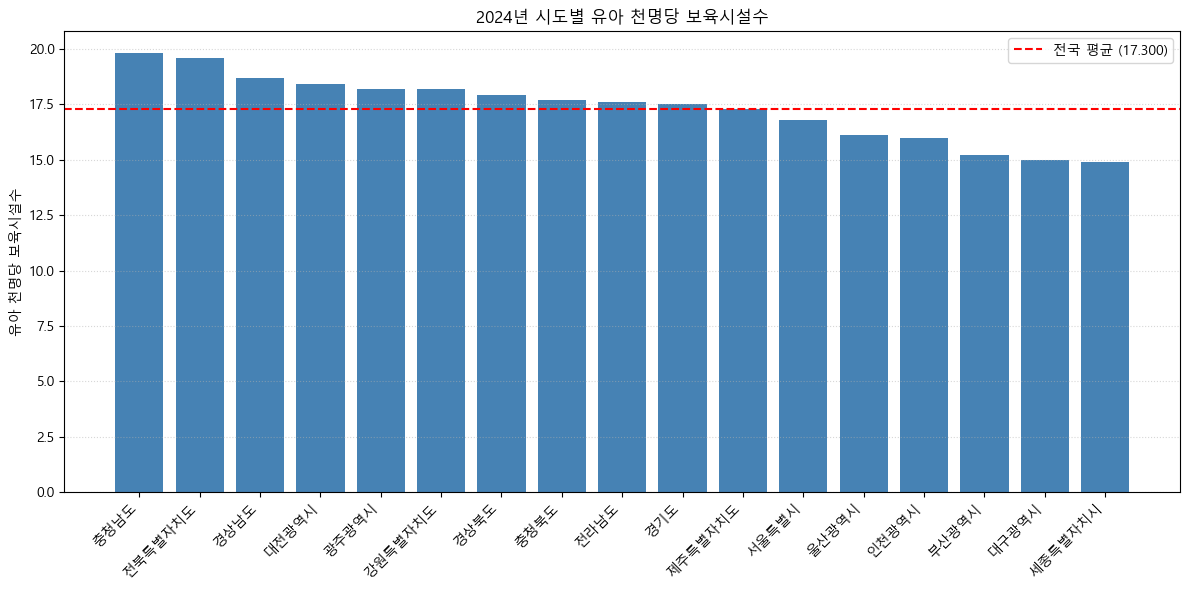

In [12]:
# 가장 최신 연도 자동 선택
year = df_facility.columns[-1]

# 특정 연도 데이터 정렬, 전국 제외
df_year = df_facility[df_facility['지역'] != '전국'][['지역', year]].copy()
df_year = df_year.sort_values(year, ascending=False)

# 전국 평균값 따로 추출
national_avg = df_facility[df_facility['지역'] == '전국'][year].values[0]

# 시각화
plt.figure(figsize=(12, 6))
plt.bar(df_year['지역'], df_year[year], color='steelblue')

# 전국 평균선 추가
plt.axhline(
    y=national_avg,
    color='red',
    linestyle='--',
    label=f'전국 평균 ({national_avg:.3f})'
)

plt.title(f'{year}년 시도별 유아 천명당 보육시설수')
plt.ylabel('유아 천명당 보육시설수')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

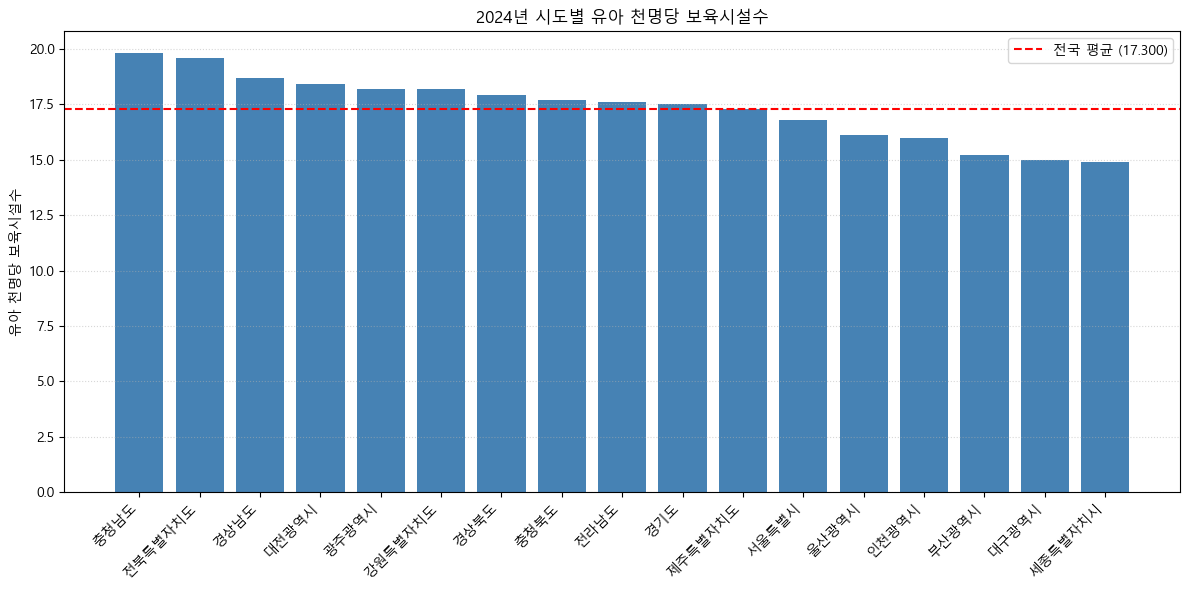

In [13]:
# 가장 최신 연도 자동 선택
year = df_facility.columns[-1]

# 특정 연도 데이터 정렬, 전국 제외
df_year = df_facility[df_facility['지역'] != '전국'][['지역', year]].copy()
df_year = df_year.sort_values(year, ascending=False)

# 전국 평균값 따로 추출
national_avg = df_facility[df_facility['지역'] == '전국'][year].values[0]

# 시각화
plt.figure(figsize=(12, 6))
plt.bar(df_year['지역'], df_year[year], color='steelblue')

# 전국 평균선 추가
plt.axhline(
    y=national_avg,
    color='red',
    linestyle='--',
    label=f'전국 평균 ({national_avg:.3f})'
)

plt.title(f'{year}년 시도별 유아 천명당 보육시설수')
plt.ylabel('유아 천명당 보육시설수')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

In [14]:
# 1. 공통 연도 추출
common_years = list(set(df_pop.columns[1:]) & set(df_facility.columns[1:]))
common_years = sorted(common_years)

# 2. long-format으로 변환
df_pop_long = df_pop.melt(
    id_vars='지역',
    value_vars=common_years,
    var_name='연도',
    value_name='인구증가율'
)

df_facility_long = df_facility.melt(
    id_vars='지역',
    value_vars=common_years,
    var_name='연도',
    value_name='보육'
)

# 3. merge
df_merged = pd.merge(df_pop_long, df_facility_long, on=['지역', '연도'])

# 4. pivot: 행=지역, 열=(연도, 변수)
df_pivoted = df_merged.pivot(index='지역', columns='연도', values=['인구증가율', '보육'])

# 5. 열 순서 정리
df_pivoted = df_pivoted.swaplevel(axis=1).sort_index(axis=1)

# 6. 확인
df_pivoted.head(len(df_pivoted))


연도       2015         2016         2017         2018         2019        2020  \
           보육  인구증가율    보육  인구증가율    보육  인구증가율    보육  인구증가율    보육 인구증가율    보육   
지역                                                                              
강원특별자치도  17.2   0.37  17.1   0.13  17.5   0.03  17.7  -0.37  17.5 -0.05  17.7   
경기도      17.2   1.43  16.6   1.54  16.7   1.26  17.2   1.74  17.4  1.25  17.5   
경상남도     17.7   0.55  17.1   0.23  17.4   0.02  18.1  -0.21  18.0 -0.28  18.2   
경상북도     15.7   0.15  15.8  -0.03  16.2  -0.24  16.7  -0.41  16.7 -0.36  17.0   
광주광역시    15.2  -0.15  15.5  -0.10  16.2  -0.27  16.7  -0.20  16.6 -0.13  17.2   
대구광역시    12.6  -0.18  12.3  -0.12  12.6  -0.37  12.9  -0.47  12.9 -0.87  13.4   
대전광역시    19.5  -0.79  19.1  -0.25  19.3  -0.77  19.5  -0.76  19.4 -0.94  19.5   
부산광역시    12.1  -0.11  12.1  -0.38  12.6  -0.76  13.2  -0.75  13.8 -0.78  14.3   
서울특별시    14.0  -0.70  14.0  -0.90  14.5  -0.78  15.2  -0.74  15.4 -0.38  15.8   
세종특별자치시  12.1  34.94  12.1  15.13  12.3  15.17  13.4  12.26  13.4  8.53  13.4   
울산광역시    13.2   0.63  12.9  -0.33  13.3  -0.85  14.1  -0.85  14.6 -0.61  15.0   
인천광역시    14.0   0.86  14.1   0.63  14.5   0.30  15.2   0.38  15.4  0.22  15.9   
전국       15.5   0.48  15.3   0.35  15.7   0.17  16.2   0.23  16.4  0.09  16.7   
전라남도     13.1   0.29  13.6  -0.20  14.3  -0.41  15.0  -0.60  15.2 -0.66  15.4   
전북특별자치도  17.4  -0.04  17.4  -0.20  17.7  -0.47  17.9  -0.80  17.9 -0.87  18.1   
제주특별자치도  15.6   3.19  14.6   3.09  14.4   2.66  14.6   1.95  15.0  0.67  15.5   
충청남도     16.9   0.82  17.0   1.07  17.4   1.11  18.1   0.62  18.2 -0.01  18.6   
충청북도     14.5   0.43  14.6   0.65  15.0   0.24  15.4   0.47  15.9  0.12  16.3   

연도             2021        2022        2023        2024        
        인구증가율    보육 인구증가율    보육 인구증가율    보육 인구증가율    보육 인구증가율  
지역                                                             
강원특별자치도 -0.03  17.9 -0.28  18.0  0.07  17.9 -0.36  18.2 -0.48  
경기도      1.12  17.7  0.86  17.7  0.33  17.8  0.60  17.5  0.75  
경상남도    -0.91  18.9 -0.88  19.1 -0.78  19.0 -0.31  18.7 -0.29  
경상북도    -1.18  17.6 -0.53  17.7 -0.75  17.5 -1.36  17.9 -0.50  
광주광역시   -0.60  17.3 -0.60  17.6 -0.58  17.9 -0.65  18.2 -0.66  
대구광역시   -0.89  13.9 -1.37  14.6 -0.80  14.8  0.63  15.0 -0.33  
대전광역시   -0.88  19.9 -0.76  19.4 -0.20  18.7 -0.07  18.4 -0.01  
부산광역시   -0.80  14.8 -1.24  15.0 -0.86  15.2 -0.54  15.2 -0.60  
서울특별시   -1.00  16.4 -1.77  16.7 -0.70  16.8 -0.30  16.8 -0.43  
세종특별자치시  4.23  13.6  4.40  13.7  3.22  14.5  0.87  14.9  1.16  
울산광역시   -1.25  15.4 -1.34  15.7 -0.82  16.1 -0.16  16.1 -0.14  
인천광역시   -0.62  16.0  0.14  15.9  0.81  16.0  1.29  16.0  1.03  
전국      -0.28  17.1 -0.46  17.3 -0.20  17.4  0.09  17.3  0.06  
전라남도    -0.99  16.5 -1.01  17.1 -0.47  17.5 -0.18  17.6 -0.39  
전북특별자치도 -0.90  18.8 -0.99  19.1 -0.70  19.2 -0.53  19.6 -0.70  
제주특별자치도  0.13  16.2 -0.01  16.6  0.33  16.9  0.14  17.3 -0.34  
충청남도    -0.40  19.3 -0.17  19.6  0.57  19.8  0.96  19.8  0.81  
충청북도    -0.17  17.1 -0.27  17.4  0.17  17.6  0.37  17.7  0.31

In [15]:
!pip install seaborn

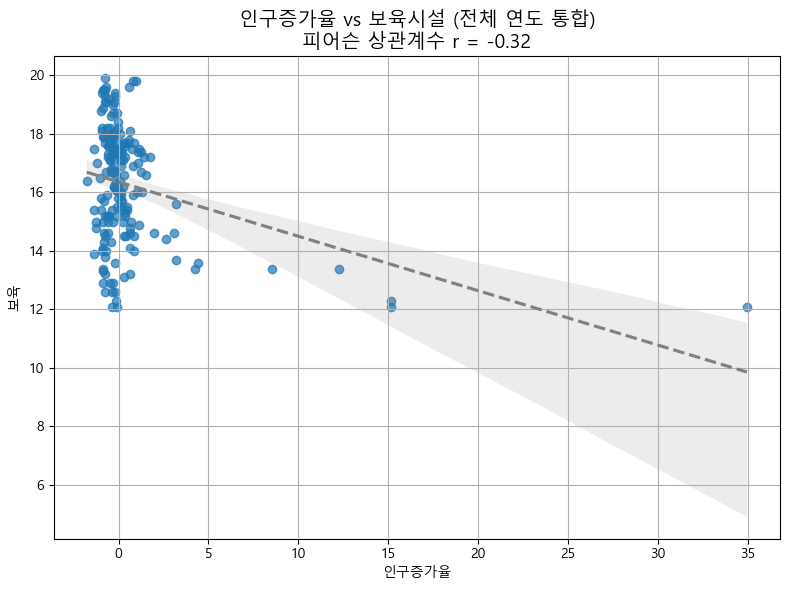

In [16]:
import seaborn as sns

# 1. 전체 연도에 대해 인구증가율 vs 보육 데이터 수집
data = []

for year in df_pivoted.columns.levels[0]:
    if (year, '인구증가율') in df_pivoted.columns and (year, '보육') in df_pivoted.columns:
        pop = df_pivoted[(year, '인구증가율')]
        facility = df_pivoted[(year, '보육')]

        for region, p, f in zip(df_pivoted.index, pop, facility):
            if pd.notna(p) and pd.notna(f):
                data.append({
                    '지역': region,
                    '연도': int(year),
                    '인구증가율': p,
                    '보육': f
                })

# 2. DataFrame 생성
df_all = pd.DataFrame(data)

# 3. 전체 상관계수 계산
r = df_all['인구증가율'].corr(df_all['보육'])

# 4. 시각화
plt.figure(figsize=(8, 6))
sns.regplot(
    data=df_all,
    x='인구증가율',
    y='보육',
    scatter_kws={'alpha': 0.7},
    line_kws={'color': 'gray', 'linestyle': 'dashed'}
)

plt.title(f"인구증가율 vs 보육시설 (전체 연도 통합)\n피어슨 상관계수 r = {r:.2f}", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

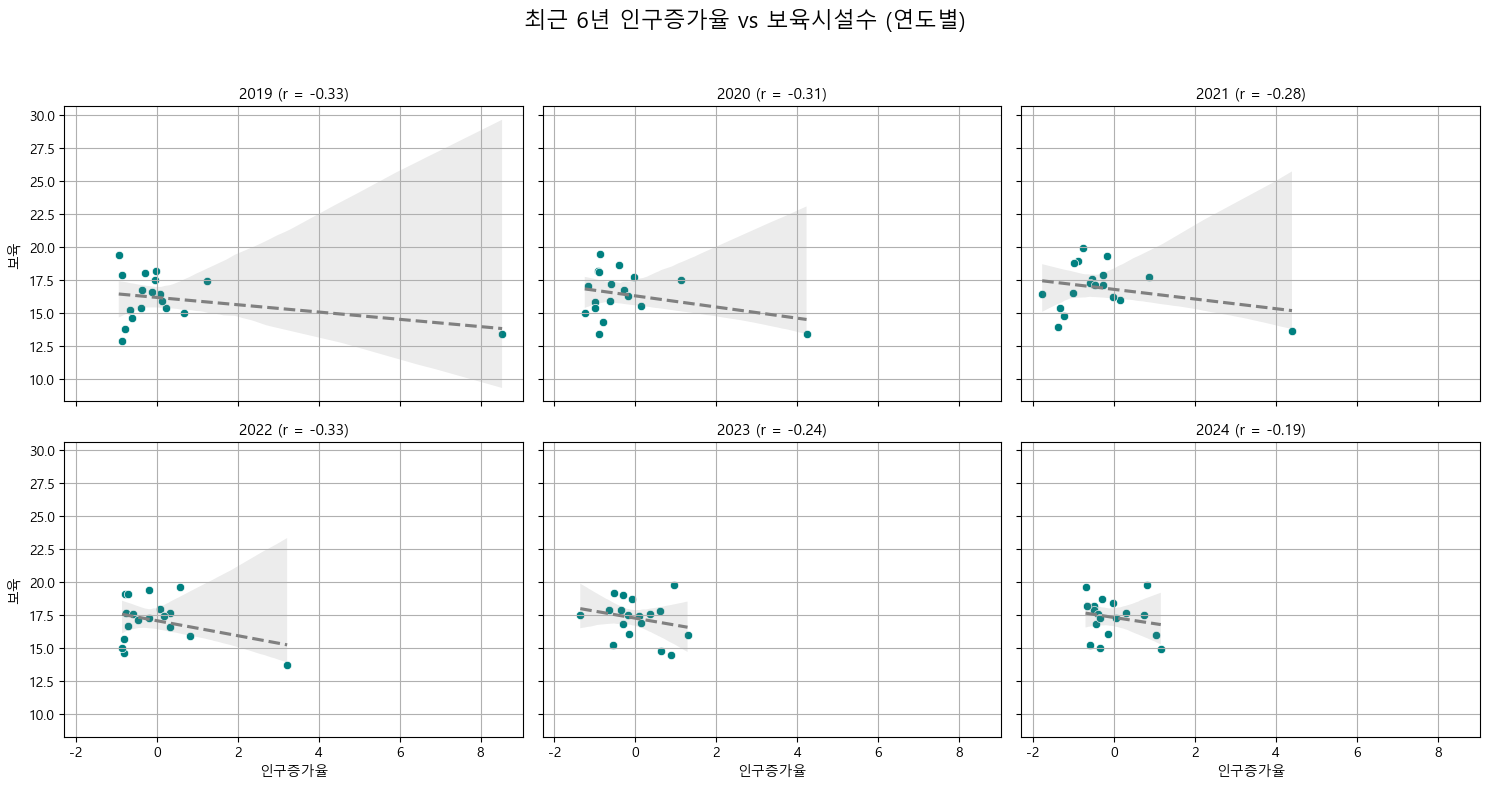

In [17]:
# 1. 최근 6년 추출
recent_years = sorted(df_all['연도'].unique())[-6:]
n_rows, n_cols = 2, 3

# 2. 플롯 준비
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()

# 3. 각 연도별 플롯
for i, year in enumerate(recent_years):
    ax = axes[i]
    subset = df_all[df_all['연도'] == year]

    # 산점도
    sns.scatterplot(data=subset, x='인구증가율', y='보육', ax=ax, color='teal')

    # 회귀선
    sns.regplot(
        data=subset,
        x='인구증가율',
        y='보육',
        ax=ax,
        scatter=False,
        color='gray',
        line_kws={'linestyle': 'dashed'}
    )

    # 상관계수 계산
    corr = subset[['인구증가율', '보육']].corr(method='pearson').iloc[0, 1]

    # 타이틀
    ax.set_title(f"{year} (r = {corr:.2f})", fontsize=11)
    ax.grid(True)

# 4. 공통 제목
fig.suptitle("최근 6년 인구증가율 vs 보육시설수 (연도별)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 인구증가율과 주거 안정성 (자가 비율 + 무상 비율 )과의 상관관계 분석

In [18]:
# 엑셀 읽기 (2줄 헤더)
factor2 = pd.read_excel("주거실태_점유형태.xlsx", engine="openpyxl", header=[0, 1])

factor2.head(len(factor2))

시도구분(1) 2021                  2022                  2023                   \
   시도구분(1)    계    자가    임차   무상    계    자가    임차   무상    계    자가    임차   무상   
0       전국  100  57.3  39.0  3.7  100  57.5  38.8  3.7  100  57.4  38.8  3.7   
1       서울  100  43.5  54.0  2.5  100  44.1  53.4  2.5  100  44.0  53.5  2.5   
2       부산  100  59.7  37.1  3.2  100  59.6  37.2  3.2  100  59.7  37.2  3.2   
3       대구  100  58.4  38.2  3.4  100  58.5  38.1  3.4  100  58.8  37.9  3.4   
4       인천  100  60.9  35.9  3.2  100  60.9  35.9  3.2  100  60.4  36.4  3.2   
5       광주  100  61.1  35.6  3.2  100  61.2  35.6  3.2  100  61.2  35.6  3.2   
6       대전  100  51.7  45.1  3.1  100  51.9  44.9  3.2  100  52.3  44.6  3.1   
7       울산  100  63.9  32.4  3.7  100  63.7  32.6  3.8  100  63.7  32.5  3.8   
8       세종  100  51.9  45.0  3.2  100  54.4  42.6  3.0  100  57.4  39.8  2.8   
9       경기  100  55.3  41.5  3.2  100  55.9  41.0  3.1  100  56.0  40.9  3.2   
10      강원  100  61.8  31.3  6.9  100  62.2  30.9  6.9  100  62.5  30.8  6.8   
11      충북  100  62.3  33.0  4.8  100  62.1  33.1  4.8  100  62.0  33.2  4.8   
12      충남  100  63.8  30.5  5.7  100  63.2  31.0  5.8  100  62.8  31.3  5.9   
13      전북  100  67.7  27.8  4.5  100  66.7  28.6  4.7  100  66.4  28.9  4.7   
14      전남  100  71.1  22.9  5.9  100  70.6  23.4  6.1  100  70.5  23.4  6.1   
15      경북  100  69.0  25.9  5.1  100  68.7  26.1  5.2  100  68.4  26.4  5.2   
16      경남  100  66.4  29.3  4.2  100  66.1  29.6  4.3  100  65.8  29.9  4.3   
17      제주  100  56.6  36.0  7.3  100  56.8  35.8  7.4  100  57.1  35.6  7.3   

   2024                   
      계    자가    임차   무상  
0   100  58.4  38.0  3.6  
1   100  44.1  53.4  2.5  
2   100  60.8  36.1  3.1  
3   100  60.2  36.6  3.3  
4   100  61.5  35.3  3.2  
5   100  62.5  34.4  3.1  
6   100  53.1  43.8  3.1  
7   100  64.1  32.2  3.7  
8   100  58.4  38.9  2.8  
9   100  57.2  39.8  3.0  
10  100  63.2  30.1  6.7  
11  100  62.8  32.4  4.7  
12  100  64.2  30.2  5.7  
13  100  67.4  28.0  4.6  
14  100  72.1  22.2  5.7  
15  100  69.5  25.4  5.1  
16  100  66.8  29.0  4.2  
17  100  58.5  34.4  7.0

In [19]:
factor2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (시도구분(1), 시도구분(1))  18 non-null     object 
 1   (2021, 계)           18 non-null     int64  
 2   (2021, 자가)          18 non-null     float64
 3   (2021, 임차)          18 non-null     float64
 4   (2021, 무상)          18 non-null     float64
 5   (2022, 계)           18 non-null     int64  
 6   (2022, 자가)          18 non-null     float64
 7   (2022, 임차)          18 non-null     float64
 8   (2022, 무상)          18 non-null     float64
 9   (2023, 계)           18 non-null     int64  
 10  (2023, 자가)          18 non-null     float64
 11  (2023, 임차)          18 non-null     float64
 12  (2023, 무상)          18 non-null     float64
 13  (2024, 계)           18 non-null     int64  
 14  (2024, 자가)          18 non-null     float64
 15  (2024, 임차)          18 non-null     float64
 16  (2024, 무상)

In [20]:
# 결측치 처리
factor2 = factor2.replace(['-', '--', '…'], np.nan)

# 연도 이름 정리 함수
import re

def clean_year(x):
    text = str(x)
    match = re.search(r'(19\d{2}|20\d{2})', text)
    if match:
        return match.group(1)
    return text

# 지역명 정리 함수
def normalize_region(x):
    text = str(x).replace('\u3000', '').strip()
    region_map = {
        '계': '전국',
        '서울': '서울특별시',
        '부산': '부산광역시',
        '대구': '대구광역시',
        '인천': '인천광역시',
        '광주': '광주광역시',
        '대전': '대전광역시',
        '울산': '울산광역시',
        '세종': '세종특별자치시',
        '경기': '경기도',
        '강원': '강원특별자치도',
        '강원도': '강원특별자치도',
        '충북': '충청북도',
        '충남': '충청남도',
        '전북': '전북특별자치도',
        '전라북도': '전북특별자치도',
        '전남': '전라남도',
        '경북': '경상북도',
        '경남': '경상남도',
        '제주': '제주특별자치도',
        '제주도': '제주특별자치도'
    }
    return region_map.get(text, text)

# 1. 지역 컬럼 찾기
region_col = [
    col for col in factor2.columns
    if ('시도구분' in str(col)) or ('행정구역' in str(col)) or ('시도' in str(col))
][0]

# 2. 임차 컬럼 찾기
rent_cols = [
    col for col in factor2.columns
    if '임차' in str(col)
]

print('지역 컬럼:', region_col)
print('임차 컬럼:', rent_cols)

# 3. 지역 컬럼과 임차 컬럼만 추출
df_housing = factor2[[region_col] + rent_cols].copy()

# 4. 열 이름 단순화
df_housing.columns = ['지역'] + [clean_year(col[0]) for col in rent_cols]

# 5. 지역명 정리
df_housing['지역'] = df_housing['지역'].apply(normalize_region)

# 6. 숫자형 변환 후 주거안정률 계산
# 교수님 예시의 주거안정률 = 자가 + 무상과 같은 의미로, 계가 100이므로 100 - 임차로 계산
for col in df_housing.columns[1:]:
    df_housing[col] = 100 - pd.to_numeric(df_housing[col], errors='coerce')

# 7. 확인
print(df_housing.columns)
df_housing.head(len(df_housing))


지역 컬럼: ('시도구분(1)', '시도구분(1)')
임차 컬럼: [('2021', '임차'), ('2022', '임차'), ('2023', '임차'), ('2024', '임차')]
Index(['지역', '2021', '2022', '2023', '2024'], dtype='object')


,지역,2021,2022,2023,2024
0,전국,61.0,61.2,61.2,62.0
1,서울특별시,46.0,46.6,46.5,46.6
2,부산광역시,62.9,62.8,62.8,63.9
3,대구광역시,61.8,61.9,62.1,63.4
4,인천광역시,64.1,64.1,63.6,64.7
5,광주광역시,64.4,64.4,64.4,65.6
6,대전광역시,54.9,55.1,55.4,56.2
7,울산광역시,67.6,67.4,67.5,67.8
8,세종특별자치시,55.0,57.4,60.2,61.1
9,경기도,58.5,59.0,59.1,60.2


선택된 연도: 2024


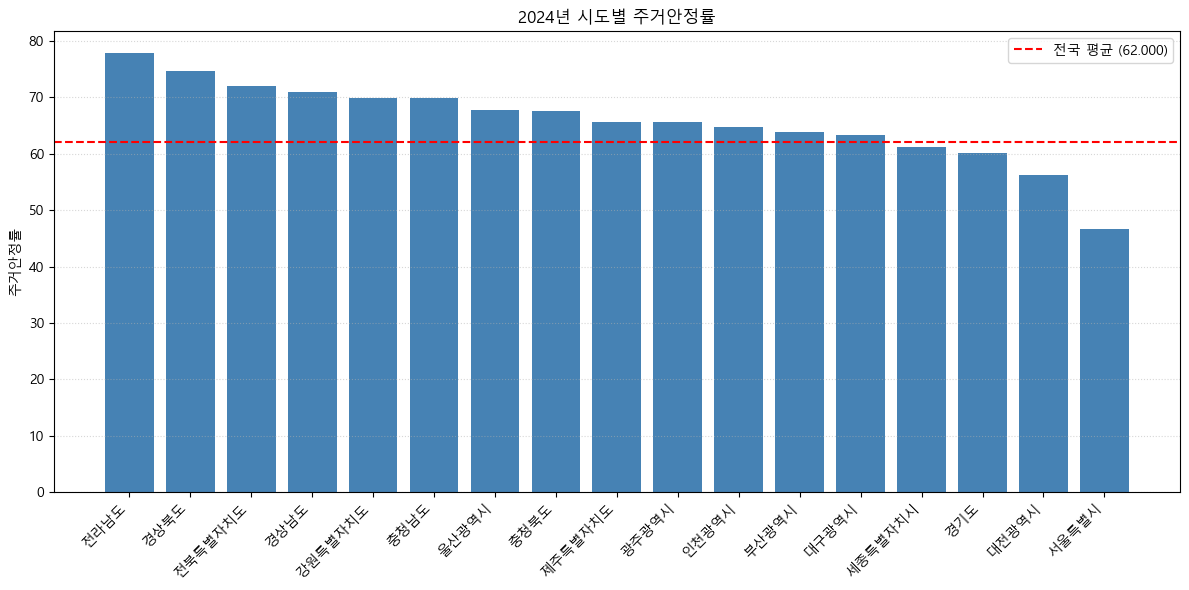

In [21]:
# 가장 최신 연도 자동 선택
year = df_housing.columns[-1]
print("선택된 연도:", year)

# 특정 연도 데이터 정렬, 전국 제외
df_year = df_housing[df_housing['지역'] != '전국'][['지역', year]].copy()
df_year = df_year.sort_values(year, ascending=False)

# 전국 평균값 따로 추출
national_avg = df_housing[df_housing['지역'] == '전국'][year].values[0]

# 시각화
plt.figure(figsize=(12, 6))
plt.bar(df_year['지역'], df_year[year], color='steelblue')

plt.axhline(
    y=national_avg,
    color='red',
    linestyle='--',
    label=f'전국 평균 ({national_avg:.3f})'
)

plt.title(f'{year}년 시도별 주거안정률')
plt.ylabel('주거안정률')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


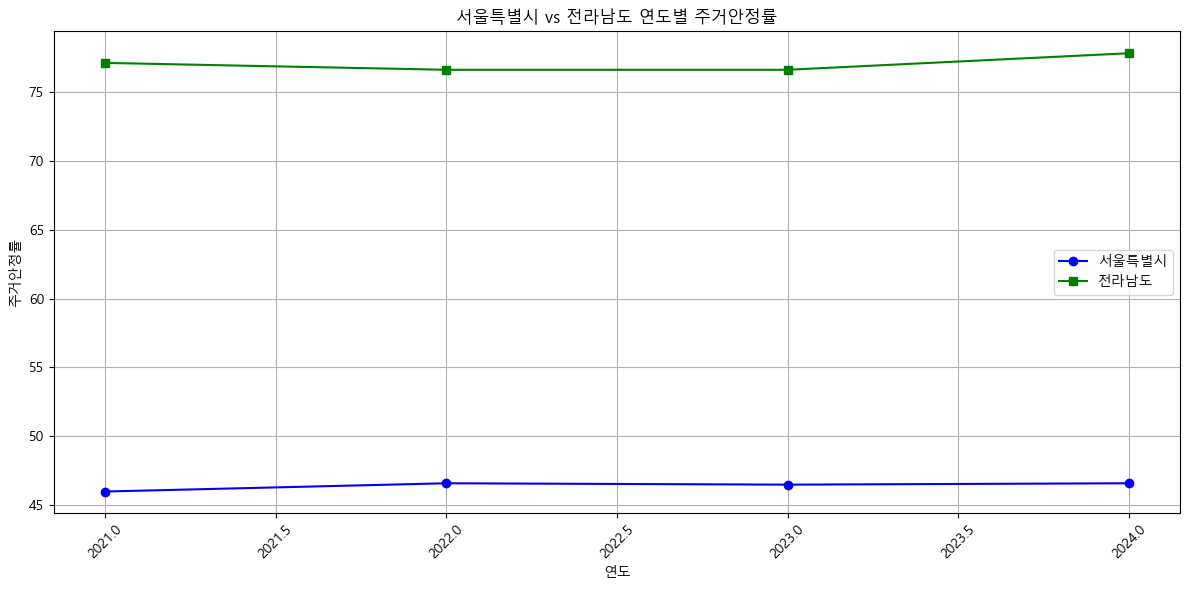

In [22]:
seoul = df_housing[df_housing['지역'] == '서울특별시'].iloc[0, 1:]
jeonnam = df_housing[df_housing['지역'] == '전라남도'].iloc[0, 1:]

# 열 이름을 정수형으로 변환
seoul.index = seoul.index.astype(int)
jeonnam.index = jeonnam.index.astype(int)

# 값도 수치형으로 변환
seoul = seoul.astype(float)
jeonnam = jeonnam.astype(float)

# x축 연도
years = seoul.index

# 시각화
plt.figure(figsize=(12, 6))
plt.plot(years, seoul, label='서울특별시', color='blue', marker='o')
plt.plot(years, jeonnam, label='전라남도', color='green', marker='s')

plt.title('서울특별시 vs 전라남도 연도별 주거안정률')
plt.xlabel('연도')
plt.ylabel('주거안정률')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [23]:
# 1. 공통 연도 추출
common_years = list(set(df_pop.columns[1:]) & set(df_housing.columns[1:]))
common_years = sorted(common_years)

print("공통 연도:", common_years)

# 2. long-format으로 변환
df_pop_long = df_pop.melt(
    id_vars='지역',
    value_vars=common_years,
    var_name='연도',
    value_name='인구증가율'
)

df_housing_long = df_housing.melt(
    id_vars='지역',
    value_vars=common_years,
    var_name='연도',
    value_name='주거안정률'
)

# 3. merge
df_merged = pd.merge(df_pop_long, df_housing_long, on=['지역', '연도'])

# 4. pivot
df_pivoted = df_merged.pivot(index='지역', columns='연도', values=['인구증가율', '주거안정률'])

# 5. 열 순서 정리
df_pivoted = df_pivoted.swaplevel(axis=1).sort_index(axis=1)

# 6. 확인
df_pivoted.head(len(df_pivoted))


공통 연도: ['2021', '2022', '2023', '2024']


연도       2021        2022        2023        2024      
        인구증가율 주거안정률 인구증가율 주거안정률 인구증가율 주거안정률 인구증가율 주거안정률
지역                                                     
강원특별자치도 -0.28  68.7  0.07  69.1 -0.36  69.2 -0.48  69.9
경기도      0.86  58.5  0.33  59.0  0.60  59.1  0.75  60.2
경상남도    -0.88  70.7 -0.78  70.4 -0.31  70.1 -0.29  71.0
경상북도    -0.53  74.1 -0.75  73.9 -1.36  73.6 -0.50  74.6
광주광역시   -0.60  64.4 -0.58  64.4 -0.65  64.4 -0.66  65.6
대구광역시   -1.37  61.8 -0.80  61.9  0.63  62.1 -0.33  63.4
대전광역시   -0.76  54.9 -0.20  55.1 -0.07  55.4 -0.01  56.2
부산광역시   -1.24  62.9 -0.86  62.8 -0.54  62.8 -0.60  63.9
서울특별시   -1.77  46.0 -0.70  46.6 -0.30  46.5 -0.43  46.6
세종특별자치시  4.40  55.0  3.22  57.4  0.87  60.2  1.16  61.1
울산광역시   -1.34  67.6 -0.82  67.4 -0.16  67.5 -0.14  67.8
인천광역시    0.14  64.1  0.81  64.1  1.29  63.6  1.03  64.7
전국      -0.46  61.0 -0.20  61.2  0.09  61.2  0.06  62.0
전라남도    -1.01  77.1 -0.47  76.6 -0.18  76.6 -0.39  77.8
전북특별자치도 -0.99  72.2 -0.70  71.4 -0.53  71.1 -0.70  72.0
제주특별자치도 -0.01  64.0  0.33  64.2  0.14  64.4 -0.34  65.6
충청남도    -0.17  69.5  0.57  69.0  0.96  68.7  0.81  69.8
충청북도    -0.27  67.0  0.17  66.9  0.37  66.8  0.31  67.6

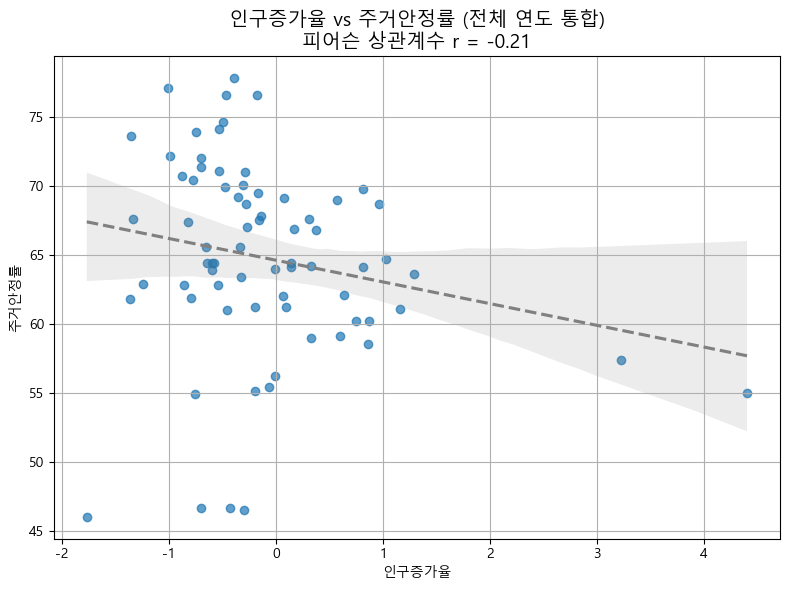

In [24]:
# 1. 전체 연도에 대해 인구증가율 vs 주거안정률 데이터 수집
data = []

for year in df_pivoted.columns.levels[0]:
    if (year, '인구증가율') in df_pivoted.columns and (year, '주거안정률') in df_pivoted.columns:
        pop = df_pivoted[(year, '인구증가율')]
        housing = df_pivoted[(year, '주거안정률')]

        for region, p, h in zip(df_pivoted.index, pop, housing):
            if pd.notna(p) and pd.notna(h):
                data.append({
                    '지역': region,
                    '연도': int(year),
                    '인구증가율': p,
                    '주거안정률': h
                })

# 2. DataFrame 생성
df_all = pd.DataFrame(data)

# 3. 전체 상관계수 계산
r = df_all['인구증가율'].corr(df_all['주거안정률'])

# 4. 시각화
plt.figure(figsize=(8, 6))
sns.regplot(
    data=df_all,
    x='인구증가율',
    y='주거안정률',
    scatter_kws={'alpha': 0.7},
    line_kws={'color': 'gray', 'linestyle': 'dashed'}
)

plt.title(f"인구증가율 vs 주거안정률 (전체 연도 통합)\n피어슨 상관계수 r = {r:.2f}", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


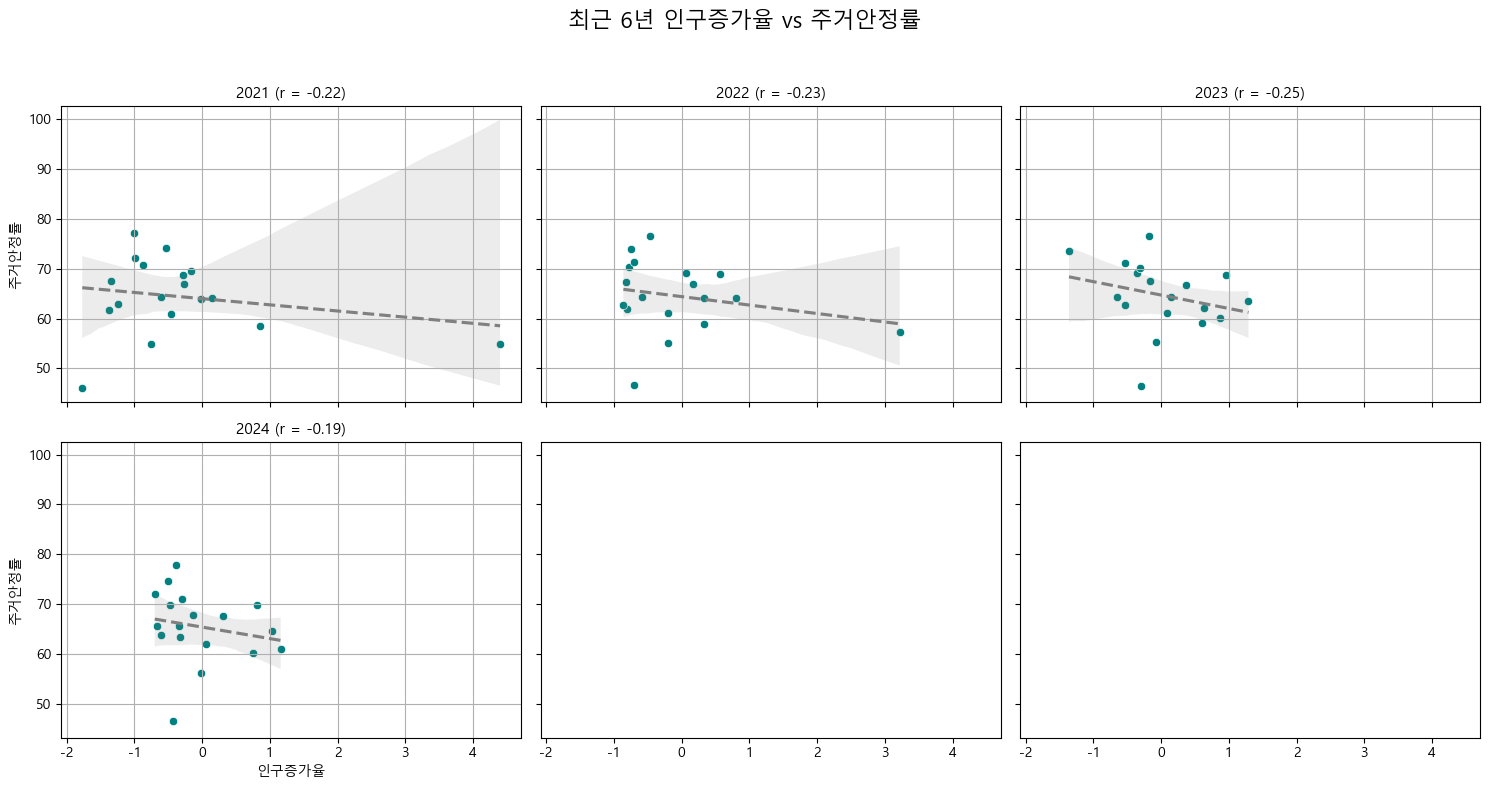

In [25]:
# 1. 최근 6년 추출
recent_years = sorted(df_all['연도'].unique())[-6:]

# 2. 플롯 준비
n_rows, n_cols = 2, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()

# 3. 각 연도별 플롯
for i, year in enumerate(recent_years):
    ax = axes[i]
    subset = df_all[df_all['연도'] == year]

    sns.scatterplot(data=subset, x='인구증가율', y='주거안정률', ax=ax, color='teal')

    sns.regplot(
        data=subset,
        x='인구증가율',
        y='주거안정률',
        ax=ax,
        scatter=False,
        color='gray',
        line_kws={'linestyle': 'dashed'}
    )

    corr = subset[['인구증가율', '주거안정률']].corr(method='pearson').iloc[0, 1]

    ax.set_title(f"{year} (r = {corr:.2f})", fontsize=11)
    ax.grid(True)

fig.suptitle("최근 6년 인구증가율 vs 주거안정률", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



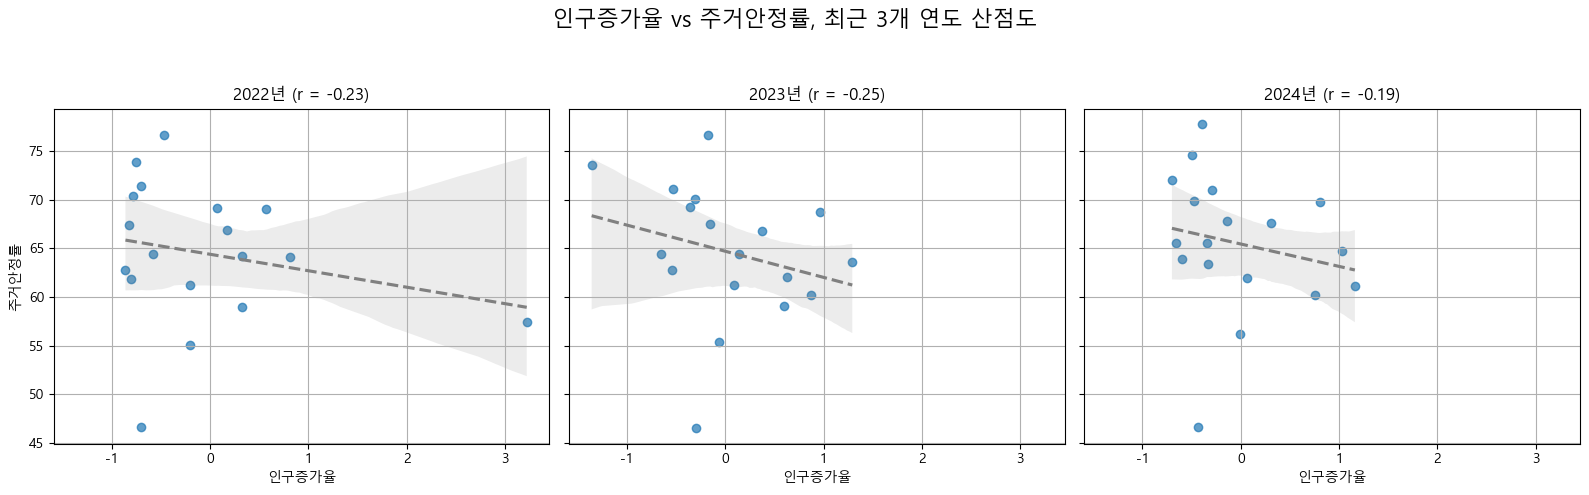

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 최근 3개 연도 선택
years = sorted(df_pivoted.columns.levels[0])[-3:]

# 2. subplot 준비
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

# 3. 연도별 산점도
for i, year in enumerate(years):
    ax = axes[i]

    x = df_pivoted[(year, '인구증가율')]
    y = df_pivoted[(year, '주거안정률')]

    # 산점도 + 회귀선
    sns.regplot(
        x=x,
        y=y,
        ax=ax,
        scatter_kws={'alpha': 0.7},
        line_kws={'linestyle': 'dashed', 'color': 'gray'}
    )

    # 상관계수
    r = x.corr(y)

    ax.set_title(f"{year}년 (r = {r:.2f})")
    ax.set_xlabel('인구증가율')

    if i == 0:
        ax.set_ylabel('주거안정률')
    else:
        ax.set_ylabel("")

    ax.grid(True)

# 4. 전체 제목
fig.suptitle("인구증가율 vs 주거안정률, 최근 3개 연도 산점도", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()



# 인구증가율과 삶의 만족도 간의 상관관계 분석

In [27]:
# 엑셀 읽기 (2줄 헤더)
factor3 = pd.read_excel("만족도.xlsx", engine="openpyxl", header=[0, 1])

factor3.head(len(factor3))

행정구역별(1) 특성별(1) 특성별(2) 2009                                 2010  ...  \
   행정구역별(1) 특성별(1) 특성별(2)    계 매우 만족 약간 만족    보통 약간 불만족 매우 불만족    계  ...   
0        전국     전체      계  100   3.3  17.6  45.3   26.5    7.4  100  ...   
1       NaN     성별     남자  100   3.9  18.4  44.9   25.4    7.3  100  ...   
2       NaN    NaN     여자  100   2.8  16.7  45.6   27.4    7.4  100  ...   
3     서울특별시     전체      계  100   3.7  20.1  44.4   24.6    7.1  100  ...   
4       NaN     성별     남자  100   4.6  20.3  44.2   23.3    7.6  100  ...   
5       NaN    NaN     여자  100   2.9  19.9  44.7   25.8    6.7  100  ...   
6     부산광역시     전체      계  100   2.6    14  45.1   29.2    9.1  100  ...   
7       NaN     성별     남자  100   2.5  13.7  46.3   28.2    9.2  100  ...   
8       NaN    NaN     여자  100   2.8  14.3  43.9     30    9.1  100  ...   
9     대구광역시     전체      계  100   2.5  13.8  46.5   29.3      8  100  ...   
10      NaN     성별     남자  100   3.2  14.8  45.8   29.2      7  100  ...   
11      NaN    NaN     여자  100   1.9  12.8    47   29.4    8.9  100  ...   
12    인천광역시     전체      계  100   3.2  16.6    48   25.5    6.7  100  ...   
13      NaN     성별     남자  100   2.3  17.9  48.1   24.9    6.9  100  ...   
14      NaN    NaN     여자  100   4.1  15.4    48   26.1    6.5  100  ...   
15    광주광역시     전체      계  100   3.4  16.3  46.3   25.9    8.1  100  ...   
16      NaN     성별     남자  100   3.9  17.2  45.3   25.2    8.4  100  ...   
17      NaN    NaN     여자  100     3  15.4  47.2   26.6    7.9  100  ...   
18    대전광역시     전체      계  100   3.5  16.5  45.4   26.9    7.6  100  ...   
19      NaN     성별     남자  100   4.1  17.5  45.3   25.5    7.6  100  ...   
20      NaN    NaN     여자  100   2.9  15.6  45.6   28.3    7.6  100  ...   
21    울산광역시     전체      계  100     3  17.7  50.5   22.2    6.6  100  ...   
22      NaN     성별     남자  100   3.5  19.3  48.8   22.5      6  100  ...   
23      NaN    NaN     여자  100   2.5  16.1  52.2     22    7.2  100  ...   
24  세종특별자치시     전체      계    -     -     -     -      -      -    -  ...   
25      NaN     성별     남자    -     -     -     -      -      -    -  ...   
26      NaN    NaN     여자    -     -     -     -      -      -    -  ...   
27      경기도     전체      계  100   3.7  18.6  44.4   25.8    7.5  100  ...   
28      NaN     성별     남자  100   4.3  20.5  42.9   24.9    7.5  100  ...   
29      NaN    NaN     여자  100   3.2  16.7    46   26.7    7.5  100  ...   
30  강원특별자치도     전체      계  100   3.4  15.8  46.3   26.7    7.7  100  ...   
31      NaN     성별     남자  100   4.2  16.8  46.8   24.5    7.8  100  ...   
32      NaN    NaN     여자  100   2.7  14.9    46   28.9    7.6  100  ...   
33     충청북도     전체      계  100   2.8  15.2  47.3   27.6    7.2  100  ...   
34      NaN     성별     남자  100   3.3    16  45.4   27.7    7.6  100  ...   
35      NaN    NaN     여자  100   2.2  14.3  49.1   27.4    6.9  100  ...   
36     충청남도     전체      계  100   4.3  19.9  46.1     24    5.7  100  ...   
37      NaN     성별     남자  100   4.2  21.2    46   23.3    5.3  100  ...   
38      NaN    NaN     여자  100   4.3  18.7  46.1   24.8    6.1  100  ...   
39  전북특별자치도     전체      계  100   2.9  16.2  42.4   29.2    9.2  100  ...   
40      NaN     성별     남자  100   3.8  16.2  42.6   28.5      9  100  ...   
41      NaN    NaN     여자  100   2.1  16.2  42.3     30    9.4  100  ...   
42     전라남도     전체      계  100   2.6  16.6  47.8     27      6  100  ...   
43      NaN     성별     남자  100   3.3  18.4  46.3     26      6  100  ...   
44      NaN    NaN     여자  100   1.9  15.1  49.2   27.9      6  100  ...   
45     경상북도     전체      계  100   2.8  16.3  44.6   28.1    8.1  100  ...   
46      NaN     성별     남자  100     4  16.8  45.1   26.6    7.5  100  ...   
47      NaN    NaN     여자  100   1.6  15.8  44.2   29.6    8.8  100  ...   
48     경상남도     전체      계  100   2.8  17.1  44.3   30.1    5.6  100  ...   
49      NaN     성별     남자  100   3.8    17  45.9   28.2    5.1  100  ...   
50      NaN    NaN     여자  100   1.8  17.2  42.8   

In [28]:
factor3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Columns: 105 entries, ('행정구역별(1)', '행정구역별(1)') to ('2025', '매우 불만족')
dtypes: float64(55), int64(11), object(39)
memory usage: 44.4+ KB


In [29]:
# 결측치 처리
factor3 = factor3.replace(['-', '--', '…'], np.nan)

# 혹시 clean_year 함수가 위에서 실행되지 않았을 경우를 대비
import re

def clean_year(x):
    text = str(x)
    match = re.search(r'(19\d{2}|20\d{2})', text)
    if match:
        return match.group(1)
    return text

# 1. 필요한 기본 컬럼 찾기
region_col = [
    col for col in factor3.columns
    if '행정구역별(1)' in str(col)
][0]

type_col_1 = [
    col for col in factor3.columns
    if '특성별(1)' in str(col)
][0]

type_col_2 = [
    col for col in factor3.columns
    if '특성별(2)' in str(col)
][0]

# 2. 매우 만족, 약간 만족 컬럼 찾기
very_sat_cols = [
    col for col in factor3.columns
    if str(col[1]).strip() == '매우 만족'
]

slightly_sat_cols = [
    col for col in factor3.columns
    if str(col[1]).strip() == '약간 만족'
]

print("지역 컬럼:", region_col)
print("특성1 컬럼:", type_col_1)
print("특성2 컬럼:", type_col_2)
print("매우 만족 컬럼:", very_sat_cols)
print("약간 만족 컬럼:", slightly_sat_cols)

# 3. 전체, 계 행만 선택
df_temp = factor3[
    (factor3[type_col_1].astype(str).str.strip() == '전체') &
    (factor3[type_col_2].astype(str).str.strip() == '계')
].copy()

# 4. 지역 컬럼만 먼저 복사
df_satisfaction = df_temp[[region_col]].copy()
df_satisfaction.columns = ['지역']

# 5. 지역명 정리
df_satisfaction['지역'] = df_satisfaction['지역'].astype(str).str.strip()

# 6. 삶의만족도 = 매우 만족 + 약간 만족
for very_col in very_sat_cols:
    year = clean_year(very_col[0])
    
    matching_slightly_cols = [
        col for col in slightly_sat_cols
        if clean_year(col[0]) == year
    ]
    
    if len(matching_slightly_cols) > 0:
        slightly_col = matching_slightly_cols[0]
        
        very_value = pd.to_numeric(df_temp[very_col], errors='coerce')
        slightly_value = pd.to_numeric(df_temp[slightly_col], errors='coerce')
        
        df_satisfaction[year] = very_value + slightly_value

# 7. 숫자형 변환
for col in df_satisfaction.columns[1:]:
    df_satisfaction[col] = pd.to_numeric(df_satisfaction[col], errors='coerce')

# 8. 확인
print(df_satisfaction.columns)
df_satisfaction.head(len(df_satisfaction))

지역 컬럼: ('행정구역별(1)', '행정구역별(1)')
특성1 컬럼: ('특성별(1)', '특성별(1)')
특성2 컬럼: ('특성별(2)', '특성별(2)')
매우 만족 컬럼: [('2009', '매우 만족'), ('2010', '매우 만족'), ('2011', '매우 만족'), ('2012', '매우 만족'), ('2013', '매우 만족'), ('2014', '매우 만족'), ('2015', '매우 만족'), ('2016', '매우 만족'), ('2017', '매우 만족'), ('2018', '매우 만족'), ('2019', '매우 만족'), ('2020', '매우 만족'), ('2021', '매우 만족'), ('2022', '매우 만족'), ('2023', '매우 만족'), ('2024', '매우 만족'), ('2025', '매우 만족')]
약간 만족 컬럼: [('2009', '약간 만족'), ('2010', '약간 만족'), ('2011', '약간 만족'), ('2012', '약간 만족'), ('2013', '약간 만족'), ('2014', '약간 만족'), ('2015', '약간 만족'), ('2016', '약간 만족'), ('2017', '약간 만족'), ('2018', '약간 만족'), ('2019', '약간 만족'), ('2020', '약간 만족'), ('2021', '약간 만족'), ('2022', '약간 만족'), ('2023', '약간 만족'), ('2024', '약간 만족'), ('2025', '약간 만족')]
Index(['지역', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016',
       '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025'],
      dtype='object')


C:\Users\parkg\AppData\Local\Temp\ipykernel_3008\3796780936.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  factor3 = factor3.replace(['-', '--', '…'], np.nan)


,지역,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,전국,20.9,30.7,23.6,33.3,34.1,42.2,33.3,42.4,29.8,40.8,39.1,42.7,34.0,43.3,42.2,40.1,45.3
3,서울특별시,23.8,35.6,26.7,32.7,35.9,43.4,36.6,43.2,32.3,42.1,40.6,46.4,34.1,43.2,41.9,46.3,44.2
6,부산광역시,16.6,28.0,22.7,34.1,31.1,43.3,29.5,42.6,28.6,41.0,33.8,40.1,31.1,41.0,40.5,37.5,44.5
9,대구광역시,16.3,22.1,18.4,29.2,30.0,34.8,30.9,35.8,24.5,35.6,34.5,33.2,31.0,41.2,37.6,36.1,39.9
12,인천광역시,19.8,24.9,21.7,29.3,32.7,42.6,31.3,38.9,27.7,40.0,43.6,42.4,31.1,39.3,39.8,28.0,46.0
15,광주광역시,19.7,29.0,21.0,34.2,30.4,42.4,34.8,47.0,32.5,43.4,40.8,43.4,38.1,46.2,43.0,40.7,46.9
18,대전광역시,20.0,34.4,24.4,34.4,38.3,49.4,36.5,44.6,31.2,43.8,42.1,41.3,39.7,51.3,49.0,47.2,48.6
21,울산광역시,20.7,26.7,22.7,35.2,36.8,37.5,30.2,45.2,30.7,44.6,39.6,40.7,36.5,41.6,41.4,40.6,45.5
24,세종특별자치시,NaN,NaN,NaN,NaN,NaN,NaN,46.4,56.4,41.6,56.7,53.2,58.7,46.1,52.8,53.3,42.8,58.5
27,경기도,22.3,31.8,24.8,32.8,34.8,42.7,33.4,42.8,28.9,38.9,39.9,44.3,33.3,42.6,41.3,35.7,46.6


선택된 연도: 2025


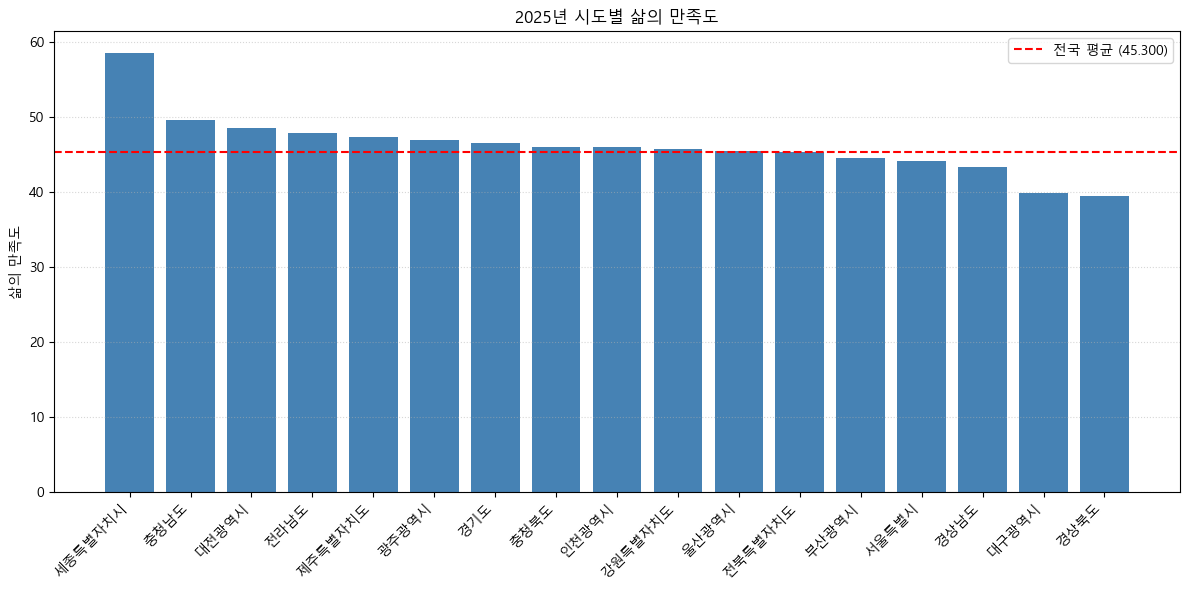

In [30]:
# 가장 최신 연도 자동 선택
year = df_satisfaction.columns[-1]
print("선택된 연도:", year)

# 특정 연도 데이터 정렬, 전국 제외
df_year = df_satisfaction[df_satisfaction['지역'] != '전국'][['지역', year]].copy()
df_year = df_year.sort_values(year, ascending=False)

# 전국 평균값 따로 추출
national_avg = df_satisfaction[df_satisfaction['지역'] == '전국'][year].values[0]

# 시각화
plt.figure(figsize=(12, 6))
plt.bar(df_year['지역'], df_year[year], color='steelblue')

plt.axhline(
    y=national_avg,
    color='red',
    linestyle='--',
    label=f'전국 평균 ({national_avg:.3f})'
)

plt.title(f'{year}년 시도별 삶의 만족도')
plt.ylabel('삶의 만족도')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

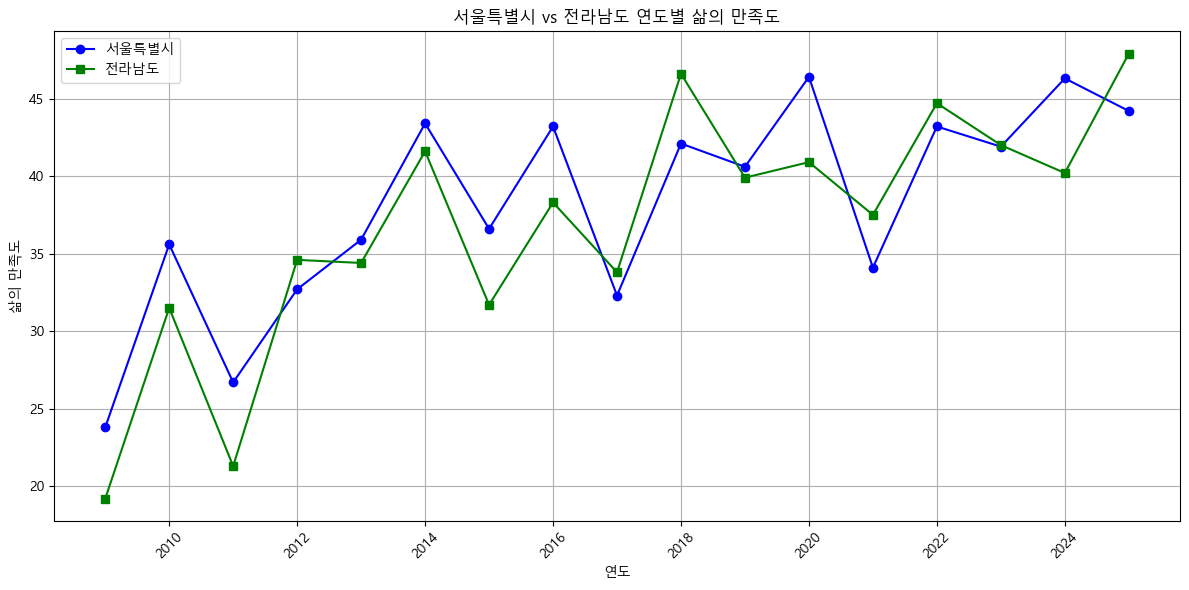

In [31]:
seoul = df_satisfaction[df_satisfaction['지역'] == '서울특별시'].iloc[0, 1:]
jeonnam = df_satisfaction[df_satisfaction['지역'] == '전라남도'].iloc[0, 1:]

# 열 이름을 정수형으로 변환
seoul.index = seoul.index.astype(int)
jeonnam.index = jeonnam.index.astype(int)

# 값도 수치형으로 변환
seoul = seoul.astype(float)
jeonnam = jeonnam.astype(float)

# x축 연도
years = seoul.index

# 시각화
plt.figure(figsize=(12, 6))
plt.plot(years, seoul, label='서울특별시', color='blue', marker='o')
plt.plot(years, jeonnam, label='전라남도', color='green', marker='s')

plt.title('서울특별시 vs 전라남도 연도별 삶의 만족도')
plt.xlabel('연도')
plt.ylabel('삶의 만족도')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [32]:
# 1. 공통 연도 추출
common_years = list(set(df_pop.columns[1:]) & set(df_satisfaction.columns[1:]))
common_years = sorted(common_years)

print("공통 연도:", common_years)

# 2. long-format으로 변환
df_pop_long = df_pop.melt(
    id_vars='지역',
    value_vars=common_years,
    var_name='연도',
    value_name='인구증가율'
)

df_satisfaction_long = df_satisfaction.melt(
    id_vars='지역',
    value_vars=common_years,
    var_name='연도',
    value_name='삶의만족도'
)

# 3. merge
df_merged = pd.merge(df_pop_long, df_satisfaction_long, on=['지역', '연도'])

# 4. pivot
df_pivoted = df_merged.pivot(index='지역', columns='연도', values=['인구증가율', '삶의만족도'])

# 5. 열 순서 정리
df_pivoted = df_pivoted.swaplevel(axis=1).sort_index(axis=1)

# 6. 확인
df_pivoted.head(len(df_pivoted))

공통 연도: ['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


연도       2015         2016         2017         2018         2019        2020  \
        삶의만족도  인구증가율 삶의만족도  인구증가율 삶의만족도  인구증가율 삶의만족도  인구증가율 삶의만족도 인구증가율 삶의만족도   
지역                                                                              
강원특별자치도  33.7   0.37  45.7   0.13  30.2   0.03  42.3  -0.37  37.4 -0.05  45.8   
경기도      33.4   1.43  42.8   1.54  28.9   1.26  38.9   1.74  39.9  1.25  44.3   
경상남도     33.5   0.55  41.7   0.23  30.0   0.02  40.4  -0.21  37.6 -0.28  45.9   
경상북도     29.0   0.15  41.8  -0.03  27.1  -0.24  40.2  -0.41  37.8 -0.36  34.4   
광주광역시    34.8  -0.15  47.0  -0.10  32.5  -0.27  43.4  -0.20  40.8 -0.13  43.4   
대구광역시    30.9  -0.18  35.8  -0.12  24.5  -0.37  35.6  -0.47  34.5 -0.87  33.2   
대전광역시    36.5  -0.79  44.6  -0.25  31.2  -0.77  43.8  -0.76  42.1 -0.94  41.3   
부산광역시    29.5  -0.11  42.6  -0.38  28.6  -0.76  41.0  -0.75  33.8 -0.78  40.1   
서울특별시    36.6  -0.70  43.2  -0.90  32.3  -0.78  42.1  -0.74  40.6 -0.38  46.4   
세종특별자치시  46.4  34.94  56.4  15.13  41.6  15.17  56.7  12.26  53.2  8.53  58.7   
울산광역시    30.2   0.63  45.2  -0.33  30.7  -0.85  44.6  -0.85  39.6 -0.61  40.7   
인천광역시    31.3   0.86  38.9   0.63  27.7   0.30  40.0   0.38  43.6  0.22  42.4   
전국       33.3   0.48  42.4   0.35  29.8   0.17  40.8   0.23  39.1  0.09  42.7   
전라남도     31.7   0.29  38.3  -0.20  33.8  -0.41  46.6  -0.60  39.9 -0.66  40.9   
전북특별자치도  28.8  -0.04  44.1  -0.20  28.5  -0.47  40.9  -0.80  36.0 -0.87  41.1   
제주특별자치도  36.0   3.19  46.1   3.09  31.2   2.66  39.0   1.95  40.2  0.67  47.9   
충청남도     32.8   0.82  42.8   1.07  28.7   1.11  38.8   0.62  37.8 -0.01  36.8   
충청북도     37.1   0.43  41.7   0.65  28.6   0.24  43.5   0.47  37.3  0.12  40.5   

연도             2021        2022        2023        2024        
        인구증가율 삶의만족도 인구증가율 삶의만족도 인구증가율 삶의만족도 인구증가율 삶의만족도 인구증가율  
지역                                                             
강원특별자치도 -0.03  37.5 -0.28  45.6  0.07  47.1 -0.36  42.2 -0.48  
경기도      1.12  33.3  0.86  42.6  0.33  41.3  0.60  35.7  0.75  
경상남도    -0.91  32.3 -0.88  42.9 -0.78  44.4 -0.31  42.9 -0.29  
경상북도    -1.18  27.5 -0.53  43.8 -0.75  38.1 -1.36  40.9 -0.50  
광주광역시   -0.60  38.1 -0.60  46.2 -0.58  43.0 -0.65  40.7 -0.66  
대구광역시   -0.89  31.0 -1.37  41.2 -0.80  37.6  0.63  36.1 -0.33  
대전광역시   -0.88  39.7 -0.76  51.3 -0.20  49.0 -0.07  47.2 -0.01  
부산광역시   -0.80  31.1 -1.24  41.0 -0.86  40.5 -0.54  37.5 -0.60  
서울특별시   -1.00  34.1 -1.77  43.2 -0.70  41.9 -0.30  46.3 -0.43  
세종특별자치시  4.23  46.1  4.40  52.8  3.22  53.3  0.87  42.8  1.16  
울산광역시   -1.25  36.5 -1.34  41.6 -0.82  41.4 -0.16  40.6 -0.14  
인천광역시   -0.62  31.1  0.14  39.3  0.81  39.8  1.29  28.0  1.03  
전국      -0.28  34.0 -0.46  43.3 -0.20  42.2  0.09  40.1  0.06  
전라남도    -0.99  37.5 -1.01  44.7 -0.47  42.0 -0.18  40.2 -0.39  
전북특별자치도 -0.90  38.2 -0.99  43.8 -0.70  47.1 -0.53  44.8 -0.70  
제주특별자치도  0.13  38.5 -0.01  48.2  0.33  44.7  0.14  43.4 -0.34  
충청남도    -0.40  40.2 -0.17  47.5  0.57  45.1  0.96  47.0  0.81  
충청북도    -0.17  35.5 -0.27  42.6  0.17  45.3  0.37  40.7  0.31

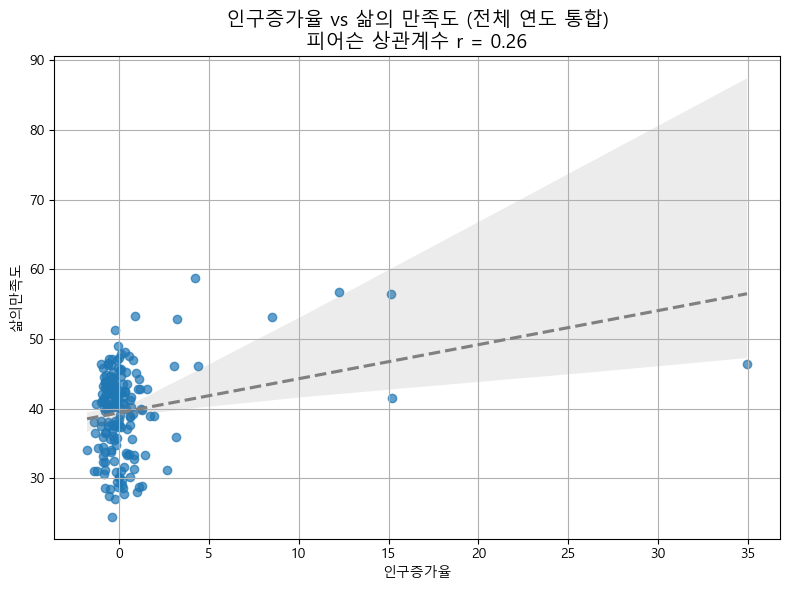

In [33]:
# 1. 전체 연도에 대해 인구증가율 vs 삶의만족도 데이터 수집
data = []

for year in df_pivoted.columns.levels[0]:
    if (year, '인구증가율') in df_pivoted.columns and (year, '삶의만족도') in df_pivoted.columns:
        pop = df_pivoted[(year, '인구증가율')]
        satisfaction = df_pivoted[(year, '삶의만족도')]

        for region, p, s in zip(df_pivoted.index, pop, satisfaction):
            if pd.notna(p) and pd.notna(s):
                data.append({
                    '지역': region,
                    '연도': int(year),
                    '인구증가율': p,
                    '삶의만족도': s
                })

# 2. DataFrame 생성
df_all = pd.DataFrame(data)

# 3. 전체 상관계수 계산
r = df_all['인구증가율'].corr(df_all['삶의만족도'])

# 4. 시각화
plt.figure(figsize=(8, 6))
sns.regplot(
    data=df_all,
    x='인구증가율',
    y='삶의만족도',
    scatter_kws={'alpha': 0.7},
    line_kws={'color': 'gray', 'linestyle': 'dashed'}
)

plt.title(f"인구증가율 vs 삶의 만족도 (전체 연도 통합)\n피어슨 상관계수 r = {r:.2f}", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

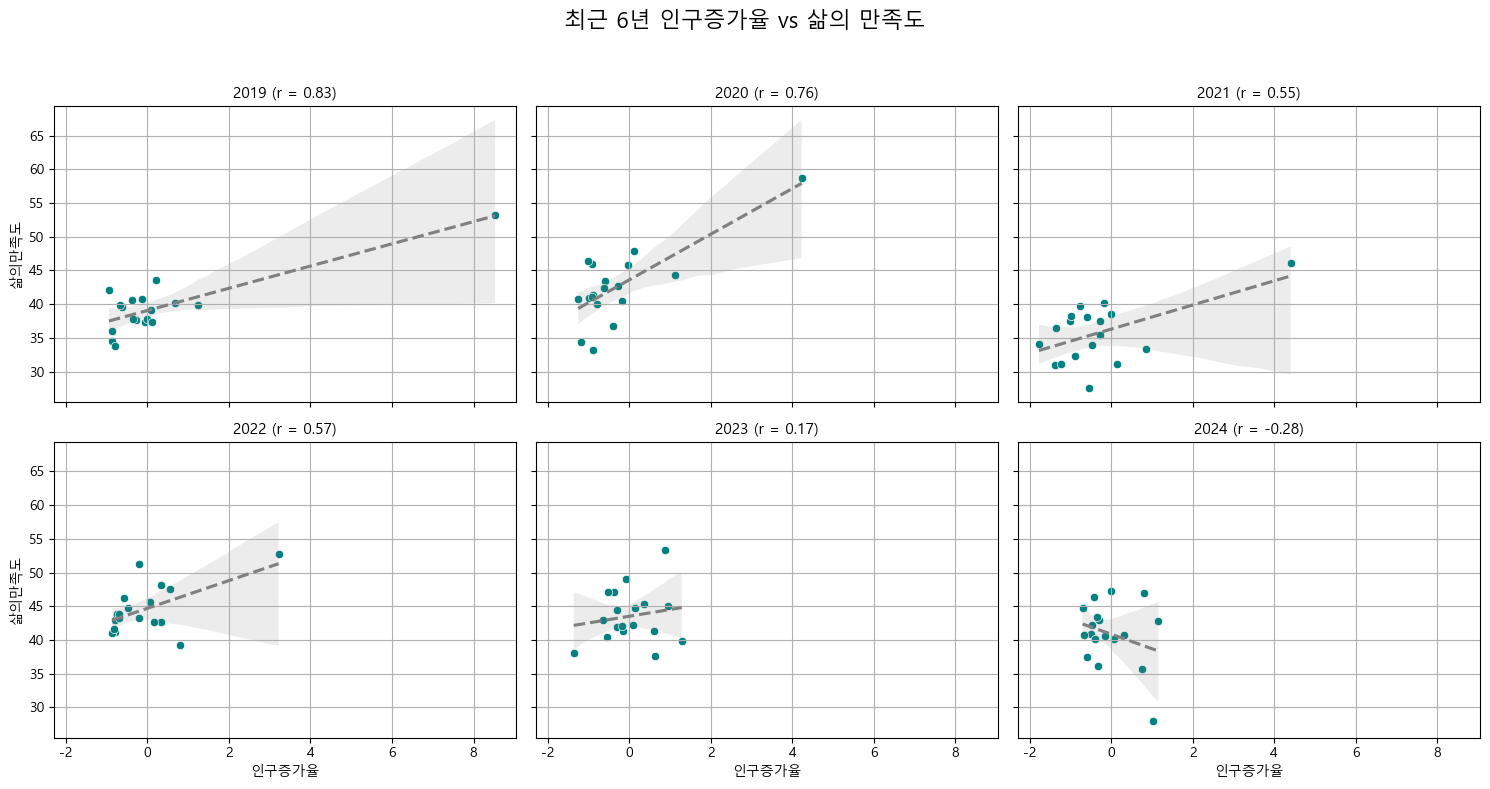

In [34]:
# 1. 최근 6년 추출
recent_years = sorted(df_all['연도'].unique())[-6:]

# 2. 플롯 준비
n_rows, n_cols = 2, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()

# 3. 각 연도별 플롯
for i, year in enumerate(recent_years):
    ax = axes[i]
    subset = df_all[df_all['연도'] == year]

    sns.scatterplot(data=subset, x='인구증가율', y='삶의만족도', ax=ax, color='teal')

    sns.regplot(
        data=subset,
        x='인구증가율',
        y='삶의만족도',
        ax=ax,
        scatter=False,
        color='gray',
        line_kws={'linestyle': 'dashed'}
    )

    corr = subset[['인구증가율', '삶의만족도']].corr(method='pearson').iloc[0, 1]

    ax.set_title(f"{year} (r = {corr:.2f})", fontsize=11)
    ax.grid(True)

fig.suptitle("최근 6년 인구증가율 vs 삶의 만족도", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 인구증가율과 주관적 소득 간의 상관관계 분석

In [35]:
# 엑셀 읽기 (2줄 헤더)
factor4 = pd.read_excel("주관적소득.xlsx", engine="openpyxl", header=[0, 1])

factor4.head(len(factor4))

행정구역별(1) 특성별(1) 특성별(2) 2011                                      2013  ...  \
   행정구역별(1) 특성별(1) 특성별(2)    계 매우 여유있음 약간  여유있음   적정함 약간 부족함 매우 부족함    계  ...   
0        전국     전체      계  100     2.8     16.9  30.8     34   15.5  100  ...   
1       NaN     성별     남자  100     3.1     18.4  31.2   33.1   14.2  100  ...   
2       NaN    NaN     여자  100     1.6     11.9  29.7     37   19.8  100  ...   
3     서울특별시     전체      계  100     1.8     17.9  32.3   31.6   16.5  100  ...   
4       NaN     성별     남자  100       2     19.6  32.7   30.3   15.4  100  ...   
5       NaN    NaN     여자  100     1.1       13  31.2   35.1   19.5  100  ...   
6     부산광역시     전체      계  100     1.8     12.9  28.9   41.3   15.2  100  ...   
7       NaN     성별     남자  100     1.7     13.7    30   40.5   14.1  100  ...   
8       NaN    NaN     여자  100     1.9     10.5  25.7   43.4   18.5  100  ...   
9     대구광역시     전체      계  100       3     16.3  33.9   31.5   15.2  100  ...   
10      NaN     성별     남자  100     3.5       17  33.9   31.5   14.1  100  ...   
11      NaN    NaN     여자  100     1.6     14.2  34.1   31.4   18.7  100  ...   
12    인천광역시     전체      계  100     5.5     14.5    25   35.7   19.3  100  ...   
13      NaN     성별     남자  100     5.9     15.9  24.8   36.2   17.2  100  ...   
14      NaN    NaN     여자  100     4.2     10.3  25.5     34   26.1  100  ...   
15    광주광역시     전체      계  100     2.9     14.8  30.2   38.3   13.8  100  ...   
16      NaN     성별     남자  100     3.6     16.4  31.4     36   12.7  100  ...   
17      NaN    NaN     여자  100     1.2     10.1  26.8   44.9     17  100  ...   
18    대전광역시     전체      계  100     4.3     18.8    30     31   15.9  100  ...   
19      NaN     성별     남자  100     4.5     20.5  30.2   29.9   14.9  100  ...   
20      NaN    NaN     여자  100     3.7     13.7  29.2   34.5   18.9  100  ...   
21    울산광역시     전체      계  100     6.1     22.3    29   29.2   13.4  100  ...   
22      NaN     성별     남자  100     7.1     23.9  28.3   27.8   12.9  100  ...   
23      NaN    NaN     여자  100     0.7     13.5  32.6   36.8   16.4  100  ...   
24  세종특별자치시     전체      계    -       -        -     -      -      -    -  ...   
25      NaN     성별     남자    -       -        -     -      -      -    -  ...   
26      NaN    NaN     여자    -       -        -     -      -      -    -  ...   
27      경기도     전체      계  100     2.5     18.2  30.3   33.5   15.5  100  ...   
28      NaN     성별     남자  100     2.5     19.3  30.3   33.9     14  100  ...   
29      NaN    NaN     여자  100     2.1       14  30.2   32.2   21.6  100  ...   
30  강원특별자치도     전체      계  100     1.7     13.6  29.7   37.6   17.4  100  ...   
31      NaN     성별     남자  100     2.2     14.9  31.2     35   16.7  100  ...   
32      NaN    NaN     여자  100     0.3      9.5    25   45.7   19.5  100  ...   
33     충청북도     전체      계  100     0.9      9.8  33.6   36.2   19.5  100  ...   
34      NaN     성별     남자  100     0.8     11.2    35   36.3   16.7  100  ...   
35      NaN    NaN     여자  100     1.3      5.6  29.2   35.8   28.1  100  ...   
36     충청남도     전체      계  100     1.8       19  26.7   34.8   17.7  100  ...   
37      NaN     성별     남자  100       2     20.7  27.6   34.1   15.7  100  ...   
38      NaN    NaN     여자  100     1.4     14.1    24   36.8   23.7  100  ...   
39  전북특별자치도     전체      계  100     4.1       18  36.9     30     11  100  ...   
40      NaN     성별     남자  100     4.7     19.7  37.4   27.9   10.3  100  ...   
41      NaN    NaN     여자  100     1.8     12.3  35.2   37.4   13.4  100  ...   
42     전라남도     전체      계  100     4.5     14.5  31.1   37.4   12.6  100  ...   
43      NaN     성별     남자  100     5.5     16.8  32.1   34.1   11.5  100  ...   
44      NaN    NaN     여자  100     1.4      8.2  28.2   46.6   15.6  100  ...   
45     경상북도     전체      계  100     2.9     19.4  32.6   32.8   12.4  100  ...   
46      NaN     성별     남자  100     3.5     22.5  31.9   30.8   11.3  100  ...   
47      NaN    NaN     여자  100    

In [36]:
factor4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 51 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   (행정구역별(1), 행정구역별(1))  18 non-null     object 
 1   (특성별(1), 특성별(1))      36 non-null     object 
 2   (특성별(2), 특성별(2))      54 non-null     object 
 3   (2011, 계)             54 non-null     object 
 4   (2011, 매우 여유있음)       54 non-null     object 
 5   (2011, 약간  여유있음)      54 non-null     object 
 6   (2011, 적정함)           54 non-null     object 
 7   (2011, 약간 부족함)        54 non-null     object 
 8   (2011, 매우 부족함)        54 non-null     object 
 9   (2013, 계)             54 non-null     object 
 10  (2013, 매우 여유있음)       54 non-null     object 
 11  (2013, 약간  여유있음)      54 non-null     object 
 12  (2013, 적정함)           54 non-null     object 
 13  (2013, 약간 부족함)        54 non-null     object 
 14  (2013, 매우 부족함)        54 non-null     object 
 15  (2015, 계)             54 

In [37]:
# 결측치 처리
factor4 = factor4.replace(['-', '--', '…'], np.nan)

# 혹시 clean_year 함수가 위에서 실행되지 않았을 경우를 대비
import re

def clean_year(x):
    text = str(x)
    match = re.search(r'(19\d{2}|20\d{2})', text)
    if match:
        return match.group(1)
    return text

# 1. 기본 컬럼 찾기
region_col = [
    col for col in factor4.columns
    if '행정구역별' in str(col) or '시도' in str(col)
][0]

# 특성별 컬럼이 있는 경우 찾기
type_cols = [
    col for col in factor4.columns
    if '특성별' in str(col)
]

print("지역 컬럼:", region_col)
print("특성 컬럼:", type_cols)

# 2. 매우 여유, 약간 여유 컬럼 찾기
very_income_cols = [
    col for col in factor4.columns
    if '매우' in str(col[1]) and '여유' in str(col[1])
]

slightly_income_cols = [
    col for col in factor4.columns
    if '약간' in str(col[1]) and '여유' in str(col[1])
]

print("매우 여유 컬럼:", very_income_cols)
print("약간 여유 컬럼:", slightly_income_cols)

# 3. 전체, 계 행만 선택
df_temp = factor4.copy()

# 특성별 컬럼이 있으면 전체, 계 조건 적용
if len(type_cols) >= 1:
    for col in type_cols:
        unique_values = df_temp[col].astype(str).str.strip().unique()
        print(col, unique_values[:10])

# 특성별(1), 특성별(2)가 있는 일반적인 경우
if len(type_cols) >= 2:
    type_col_1 = type_cols[0]
    type_col_2 = type_cols[1]

    df_temp = factor4[
        (factor4[type_col_1].astype(str).str.strip().isin(['전체', '계'])) &
        (factor4[type_col_2].astype(str).str.strip().isin(['전체', '계']))
    ].copy()

# 특성별 컬럼이 1개만 있는 경우
elif len(type_cols) == 1:
    type_col_1 = type_cols[0]

    df_temp = factor4[
        factor4[type_col_1].astype(str).str.strip().isin(['전체', '계'])
    ].copy()

# 만약 조건 적용 후 비어 있으면 원본 사용
if len(df_temp) == 0:
    df_temp = factor4.copy()

# 4. 지역 컬럼만 먼저 복사
df_income = df_temp[[region_col]].copy()
df_income.columns = ['지역']

# 5. 지역명 정리
df_income['지역'] = df_income['지역'].astype(str).str.strip()

# 6. 주관적소득 = 매우 여유있음 + 약간 여유있음
for very_col in very_income_cols:
    year = clean_year(very_col[0])

    matching_slightly_cols = [
        col for col in slightly_income_cols
        if clean_year(col[0]) == year
    ]

    if len(matching_slightly_cols) > 0:
        slightly_col = matching_slightly_cols[0]

        very_value = pd.to_numeric(df_temp[very_col], errors='coerce')
        slightly_value = pd.to_numeric(df_temp[slightly_col], errors='coerce')

        df_income[year] = very_value + slightly_value

# 7. 숫자형 변환
for col in df_income.columns[1:]:
    df_income[col] = pd.to_numeric(df_income[col], errors='coerce')

# 8. 지역이 nan인 행 제거
df_income = df_income[df_income['지역'].notna()]
df_income = df_income[df_income['지역'] != 'nan']

# 9. 확인
print(df_income.columns)
df_income.head(len(df_income))

지역 컬럼: ('행정구역별(1)', '행정구역별(1)')
특성 컬럼: [('특성별(1)', '특성별(1)'), ('특성별(2)', '특성별(2)')]
매우 여유 컬럼: [('2011', '매우 여유있음'), ('2013', '매우 여유있음'), ('2015', '매우 여유있음'), ('2017', '매우 여유있음'), ('2019', '매우 여유있음'), ('2021', '매우 여유있음'), ('2023', '매우 여유있음'), ('2025', '매우 여유있음')]
약간 여유 컬럼: [('2011', '약간  여유있음'), ('2013', '약간  여유있음'), ('2015', '약간  여유있음'), ('2017', '약간  여유있음'), ('2019', '약간  여유있음'), ('2021', '약간  여유있음'), ('2023', '약간  여유있음'), ('2025', '약간  여유있음')]
('특성별(1)', '특성별(1)') ['전체' '성별' 'nan']
('특성별(2)', '특성별(2)') ['계' '남자' '여자']
Index(['지역', '2011', '2013', '2015', '2017', '2019', '2021', '2023', '2025'], dtype='object')


C:\Users\parkg\AppData\Local\Temp\ipykernel_3008\1550820486.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  factor4 = factor4.replace(['-', '--', '…'], np.nan)


,지역,2011,2013,2015,2017,2019,2021,2023,2025
0,전국,19.7,8.5,8.3,10.8,10.8,11.8,13.6,15.6
3,서울특별시,19.7,9.8,9.9,14.2,12.1,12.7,15.5,18.5
6,부산광역시,14.7,8.1,6.6,6.7,7.8,9.4,12.5,14.6
9,대구광역시,19.3,7.1,8.4,10.3,10.0,8.0,10.6,15.6
12,인천광역시,20.0,7.2,7.5,8.0,11.2,13.0,13.2,14.1
15,광주광역시,17.7,6.5,5.6,9.2,8.5,13.7,12.6,15.5
18,대전광역시,23.1,9.4,10.0,13.0,10.9,12.3,13.9,16.2
21,울산광역시,28.4,9.4,8.5,8.1,11.1,13.1,11.7,14.4
24,세종특별자치시,NaN,NaN,12.7,19.5,13.4,14.2,18.6,20.6
27,경기도,20.7,9.7,8.1,11.0,12.3,12.6,14.6,15.8


선택된 연도: 2025


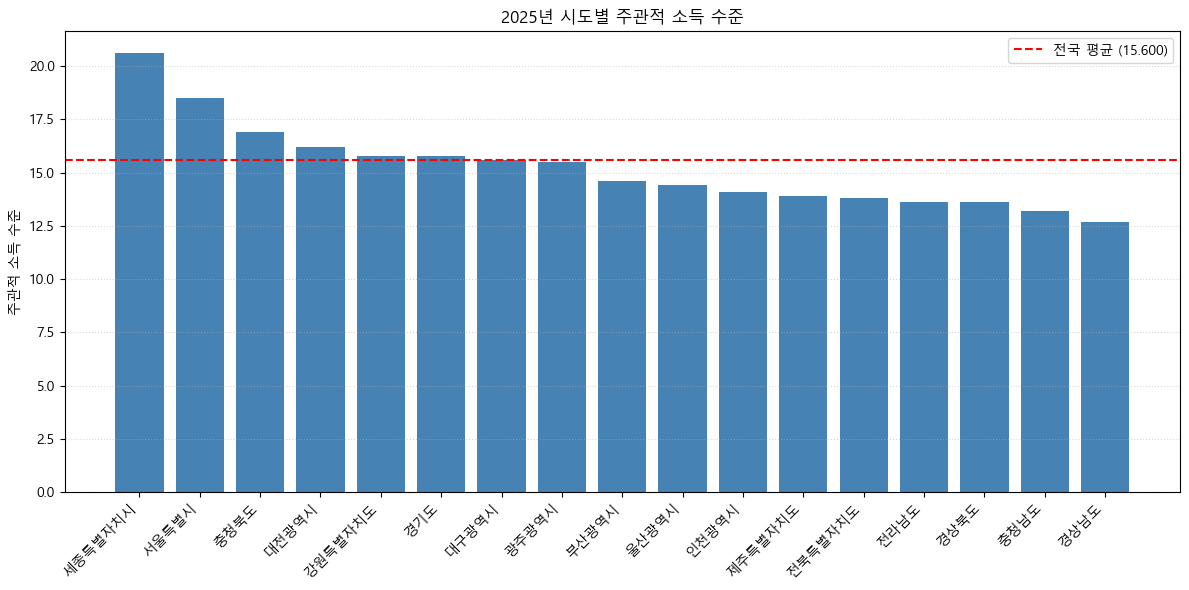

In [38]:
# 가장 최신 연도 자동 선택
year = df_income.columns[-1]
print("선택된 연도:", year)

# 특정 연도 데이터 정렬, 전국 제외
df_year = df_income[df_income['지역'] != '전국'][['지역', year]].copy()
df_year = df_year.sort_values(year, ascending=False)

# 전국 평균값 따로 추출
national_avg = df_income[df_income['지역'] == '전국'][year].values[0]

# 시각화
plt.figure(figsize=(12, 6))
plt.bar(df_year['지역'], df_year[year], color='steelblue')

plt.axhline(
    y=national_avg,
    color='red',
    linestyle='--',
    label=f'전국 평균 ({national_avg:.3f})'
)

plt.title(f'{year}년 시도별 주관적 소득 수준')
plt.ylabel('주관적 소득 수준')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

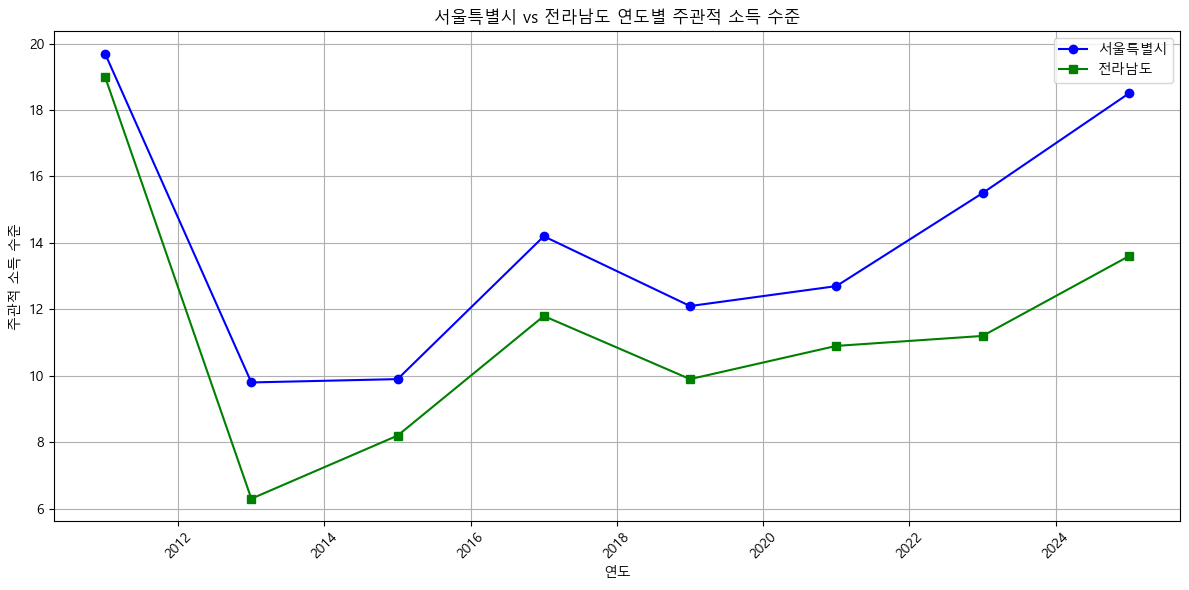

In [39]:
seoul = df_income[df_income['지역'] == '서울특별시'].iloc[0, 1:]
jeonnam = df_income[df_income['지역'] == '전라남도'].iloc[0, 1:]

# 열 이름을 정수형으로 변환
seoul.index = seoul.index.astype(int)
jeonnam.index = jeonnam.index.astype(int)

# 값도 수치형으로 변환
seoul = seoul.astype(float)
jeonnam = jeonnam.astype(float)

# x축 연도
years = seoul.index

# 시각화
plt.figure(figsize=(12, 6))
plt.plot(years, seoul, label='서울특별시', color='blue', marker='o')
plt.plot(years, jeonnam, label='전라남도', color='green', marker='s')

plt.title('서울특별시 vs 전라남도 연도별 주관적 소득 수준')
plt.xlabel('연도')
plt.ylabel('주관적 소득 수준')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [40]:
# 1. 공통 연도 추출
common_years = list(set(df_pop.columns[1:]) & set(df_income.columns[1:]))
common_years = sorted(common_years)

print("공통 연도:", common_years)

# 2. long-format으로 변환
df_pop_long = df_pop.melt(
    id_vars='지역',
    value_vars=common_years,
    var_name='연도',
    value_name='인구증가율'
)

df_income_long = df_income.melt(
    id_vars='지역',
    value_vars=common_years,
    var_name='연도',
    value_name='주관적소득'
)

# 3. merge
df_merged = pd.merge(df_pop_long, df_income_long, on=['지역', '연도'])

# 4. pivot
df_pivoted = df_merged.pivot(index='지역', columns='연도', values=['인구증가율', '주관적소득'])

# 5. 열 순서 정리
df_pivoted = df_pivoted.swaplevel(axis=1).sort_index(axis=1)

# 6. 확인
df_pivoted.head(len(df_pivoted))

공통 연도: ['2015', '2017', '2019', '2021', '2023']


연도        2015         2017        2019        2021        2023      
         인구증가율 주관적소득  인구증가율 주관적소득 인구증가율 주관적소득 인구증가율 주관적소득 인구증가율 주관적소득
지역                                                                   
강원특별자치도   0.37   9.0   0.03   9.7 -0.05   9.5 -0.28  11.6 -0.36  11.3
경기도       1.43   8.1   1.26  11.0  1.25  12.3  0.86  12.6  0.60  14.6
경상남도      0.55   8.4   0.02   8.9 -0.28   9.3 -0.88   9.9 -0.31  11.7
경상북도      0.15   8.1  -0.24  10.0 -0.36   9.8 -0.53   8.3 -1.36  11.0
광주광역시    -0.15   5.6  -0.27   9.2 -0.13   8.5 -0.60  13.7 -0.65  12.6
대구광역시    -0.18   8.4  -0.37  10.3 -0.87  10.0 -1.37   8.0  0.63  10.6
대전광역시    -0.79  10.0  -0.77  13.0 -0.94  10.9 -0.76  12.3 -0.07  13.9
부산광역시    -0.11   6.6  -0.76   6.7 -0.78   7.8 -1.24   9.4 -0.54  12.5
서울특별시    -0.70   9.9  -0.78  14.2 -0.38  12.1 -1.77  12.7 -0.30  15.5
세종특별자치시  34.94  12.7  15.17  19.5  8.53  13.4  4.40  14.2  0.87  18.6
울산광역시     0.63   8.5  -0.85   8.1 -0.61  11.1 -1.34  13.1 -0.16  11.7
인천광역시     0.86   7.5   0.30   8.0  0.22  11.2  0.14  13.0  1.29  13.2
전국        0.48   8.3   0.17  10.8  0.09  10.8 -0.46  11.8  0.09  13.6
전라남도      0.29   8.2  -0.41  11.8 -0.66   9.9 -1.01  10.9 -0.18  11.2
전북특별자치도  -0.04   7.2  -0.47  10.7 -0.87  10.1 -0.99  13.7 -0.53  16.4
제주특별자치도   3.19   6.9   2.66  11.9  0.67   8.4 -0.01  13.1  0.14  10.8
충청남도      0.82   9.4   1.11   8.4 -0.01  11.5 -0.17  13.2  0.96  15.4
충청북도      0.43   6.9   0.24  10.6  0.12   9.1 -0.27  13.7  0.37  14.2

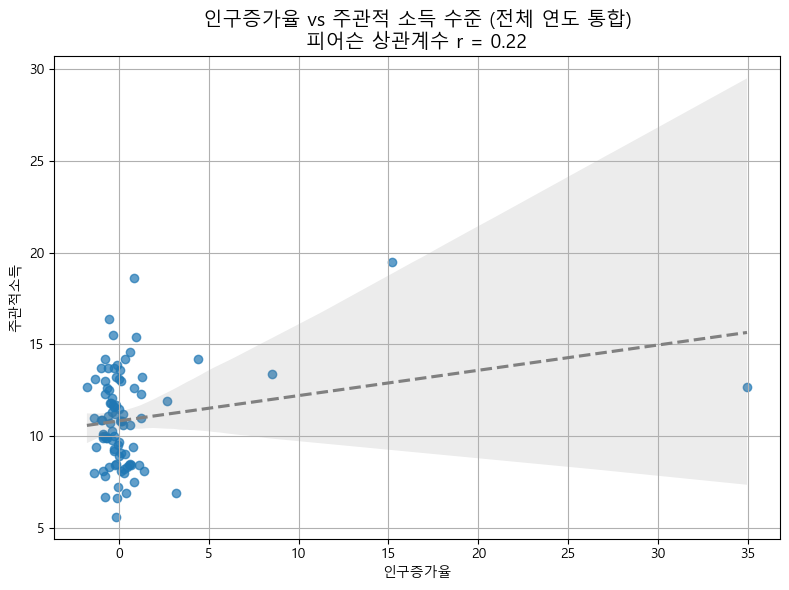

In [41]:
# 1. 전체 연도에 대해 인구증가율 vs 주관적소득 데이터 수집
data = []

for year in df_pivoted.columns.levels[0]:
    if (year, '인구증가율') in df_pivoted.columns and (year, '주관적소득') in df_pivoted.columns:
        pop = df_pivoted[(year, '인구증가율')]
        income = df_pivoted[(year, '주관적소득')]

        for region, p, inc in zip(df_pivoted.index, pop, income):
            if pd.notna(p) and pd.notna(inc):
                data.append({
                    '지역': region,
                    '연도': int(year),
                    '인구증가율': p,
                    '주관적소득': inc
                })

# 2. DataFrame 생성
df_all = pd.DataFrame(data)

# 3. 전체 상관계수 계산
r = df_all['인구증가율'].corr(df_all['주관적소득'])

# 4. 시각화
plt.figure(figsize=(8, 6))
sns.regplot(
    data=df_all,
    x='인구증가율',
    y='주관적소득',
    scatter_kws={'alpha': 0.7},
    line_kws={'color': 'gray', 'linestyle': 'dashed'}
)

plt.title(f"인구증가율 vs 주관적 소득 수준 (전체 연도 통합)\n피어슨 상관계수 r = {r:.2f}", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

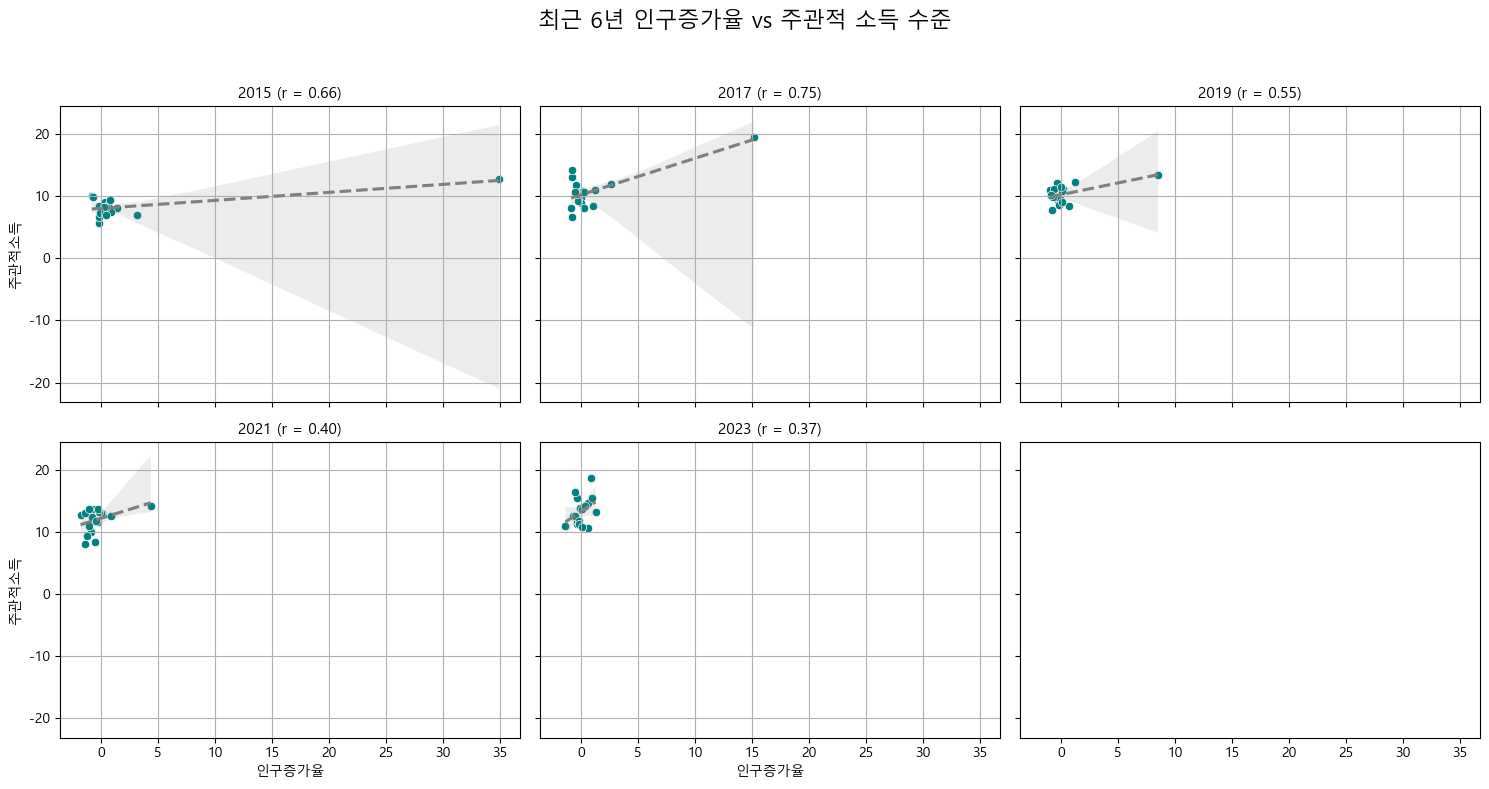

In [42]:
# 1. 최근 6년 추출
recent_years = sorted(df_all['연도'].unique())[-6:]

# 2. 플롯 준비
n_rows, n_cols = 2, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()

# 3. 각 연도별 플롯
for i, year in enumerate(recent_years):
    ax = axes[i]
    subset = df_all[df_all['연도'] == year]

    sns.scatterplot(data=subset, x='인구증가율', y='주관적소득', ax=ax, color='teal')

    sns.regplot(
        data=subset,
        x='인구증가율',
        y='주관적소득',
        ax=ax,
        scatter=False,
        color='gray',
        line_kws={'linestyle': 'dashed'}
    )

    corr = subset[['인구증가율', '주관적소득']].corr(method='pearson').iloc[0, 1]

    ax.set_title(f"{year} (r = {corr:.2f})", fontsize=11)
    ax.grid(True)

fig.suptitle("최근 6년 인구증가율 vs 주관적 소득 수준", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 모든 요소 고려

In [43]:
from functools import reduce
import re

# 연도 정리 함수
def clean_year(x):
    text = str(x)
    match = re.search(r'(19\d{2}|20\d{2})', text)
    if match:
        return match.group(1)
    return text

# 지역명 정리 함수
def normalize_region(x):
    x = str(x).replace('\u3000', '').strip()
    region_map = {
        '계': '전국',
        '강원도': '강원특별자치도',
        '전라북도': '전북특별자치도',
        '제주도': '제주특별자치도'
    }
    return region_map.get(x, x)

# 지역 컬럼 찾기
def find_region_col(df):
    region_candidates = [
        col for col in df.columns
        if ('행정구역' in str(col)) or ('시도' in str(col)) or ('지역' in str(col))
    ]
    if len(region_candidates) == 0:
        raise ValueError("지역 컬럼을 찾지 못했습니다.")
    return region_candidates[0]

# 특정 단어가 들어간 컬럼 찾기
def find_cols_by_keywords(df, keywords):
    result = []
    for col in df.columns:
        text = str(col)
        if all(keyword in text for keyword in keywords):
            result.append(col)
    return result

# 일반적인 지역, 연도형 데이터프레임 만들기
def make_region_year_df(df, value_cols):
    region_col = find_region_col(df)

    if len(value_cols) == 0:
        raise ValueError("값 컬럼을 찾지 못했습니다.")

    temp = df[[region_col] + value_cols].copy()
    temp.columns = ['지역'] + [
        clean_year(col[0]) if isinstance(col, tuple) else clean_year(col)
        for col in value_cols
    ]

    temp['지역'] = temp['지역'].apply(normalize_region)

    for col in temp.columns[1:]:
        temp[col] = pd.to_numeric(temp[col], errors='coerce')

    return temp


# 1. 맞벌이 가구
factor_dual = pd.read_excel("맞벌이가구.xlsx", engine="openpyxl", header=[0, 1])

dual_cols = [
    col for col in factor_dual.columns
    if '맞벌이가구비율' in str(col)
]

df_dual = make_region_year_df(factor_dual, dual_cols)


# 2. 물가지수
factor_price = pd.read_excel("물가지수.xlsx", engine="openpyxl", header=0)

factor_price['도시별'] = factor_price['도시별'].ffill()

df_price = factor_price[
    factor_price['지출목적별'].astype(str).str.contains('총지수', na=False)
].copy()

df_price['지역'] = factor_price['도시별'].apply(normalize_region)

valid_regions = [
    '전국',
    '서울특별시', '부산광역시', '대구광역시', '인천광역시',
    '광주광역시', '대전광역시', '울산광역시', '세종특별자치시',
    '경기도', '강원특별자치도',
    '충청북도', '충청남도', '전북특별자치도', '전라남도',
    '경상북도', '경상남도', '제주특별자치도'
]

df_price = df_price[df_price['지역'].isin(valid_regions)].copy()

price_year_cols = [
    col for col in df_price.columns
    if str(col).isdigit()
]

df_price = df_price[['지역'] + price_year_cols].copy()

for col in price_year_cols:
    df_price[col] = pd.to_numeric(df_price[col], errors='coerce')


# 3. 범죄율
factor_crime = pd.read_excel("범죄율.xlsx", engine="openpyxl", header=[0, 1])

crime_cols = [
    col for col in factor_crime.columns
    if ('범죄발생건수' in str(col)) and (('천명당' in str(col)) or ('천 명당' in str(col)))
]

df_crime = make_region_year_df(factor_crime, crime_cols)


# 4. 청년고용률
factor_youth = pd.read_excel("청년고용률.xlsx", engine="openpyxl", header=0)

region_col = '시도별'

youth_year_cols = [
    col for col in factor_youth.columns
    if str(col).isdigit()
]

df_youth = factor_youth[[region_col] + youth_year_cols].copy()

df_youth.columns = ['지역'] + [str(col) for col in youth_year_cols]

df_youth['지역'] = df_youth['지역'].apply(normalize_region)

for col in df_youth.columns[1:]:
    df_youth[col] = pd.to_numeric(df_youth[col], errors='coerce')


# 5. 어린이집 현황, 현원율 = 현원 / 정원 * 100
factor_child = pd.read_excel("어린이집현황.xlsx", engine="openpyxl", header=0)

factor_child['지역'] = factor_child['시도별'].ffill().apply(normalize_region)

child_year_cols = [
    col for col in factor_child.columns
    if str(col).isdigit()
]

capacity_df = factor_child[factor_child['항목'] == '정원'][['지역'] + child_year_cols].copy()
current_df = factor_child[factor_child['항목'] == '현원'][['지역'] + child_year_cols].copy()

capacity_df = capacity_df.set_index('지역')
current_df = current_df.set_index('지역')

for col in child_year_cols:
    capacity_df[col] = pd.to_numeric(capacity_df[col], errors='coerce')
    current_df[col] = pd.to_numeric(current_df[col], errors='coerce')

df_childcare = (current_df / capacity_df * 100).reset_index()


# 6. 종합 분석에 사용할 변수 매핑
data_sources = {
    '인구증가율': df_pop,
    '보육': df_facility,
    '주거안정률': df_housing,
    '삶의만족도': df_satisfaction,
    '주관적소득': df_income,
    '맞벌이가구비율': df_dual,
    '물가지수': df_price,
    '범죄율': df_crime,
    '청년고용률': df_youth,
    '어린이집현원율': df_childcare
}


# 7. 각 데이터프레임의 연도 컬럼만 추출
def get_year_columns(df):
    return [str(col) for col in df.columns[1:] if str(col).isdigit()]

common_years = set(get_year_columns(df_pop))

for df in data_sources.values():
    common_years &= set(get_year_columns(df))

common_years = sorted(common_years)

print("공통 연도:", common_years)

if len(common_years) == 0:
    raise ValueError("공통 연도가 없습니다. 각 데이터프레임의 연도 컬럼을 확인해야 합니다.")


# 8. long-format으로 변환 후 병합
long_dfs = []

for var_name, df in data_sources.items():
    temp = df[['지역'] + common_years].copy()
    temp['지역'] = temp['지역'].astype(str).str.strip()

    df_long = temp.melt(
        id_vars='지역',
        value_vars=common_years,
        var_name='연도',
        value_name=var_name
    )

    df_long['연도'] = df_long['연도'].astype(int)
    long_dfs.append(df_long)

df_merged = reduce(
    lambda left, right: pd.merge(left, right, on=['지역', '연도']),
    long_dfs
)


# 9. pivot 구조로 변환
df_pivoted = df_merged.pivot(index='지역', columns='연도')

df_pivoted = df_pivoted.swaplevel(axis=1).sort_index(axis=1)
df_pivoted.columns.name = None

print("df_pivoted에 들어간 변수:")
print(df_pivoted.columns.get_level_values(1).unique())

df_pivoted.head(len(df_pivoted))


공통 연도: ['2021', '2023']
df_pivoted에 들어간 변수:
Index(['맞벌이가구비율', '물가지수', '범죄율', '보육', '삶의만족도', '어린이집현원율', '인구증가율', '주거안정률',
       '주관적소득', '청년고용률'],
      dtype='object')


연도         2021                                                               \
        맞벌이가구비율    물가지수   범죄율    보육 삶의만족도    어린이집현원율 인구증가율 주거안정률 주관적소득 청년고용률   
지역                                                                             
강원특별자치도    52.1  102.80  25.7  17.9  37.5  73.630931 -0.28  68.7  11.6  40.2   
경기도        44.4  102.57  26.3  17.7  33.3  79.225076  0.86  58.5  12.6  45.5   
경상남도       48.1  102.53  26.5  18.9  32.3  73.737546 -0.88  70.7   9.9  39.4   
경상북도       52.9  102.74  25.0  17.6  27.5  70.796939 -0.53  74.1   8.3  38.7   
광주광역시      46.1  102.57  27.3  17.3  38.1  69.741303 -0.60  64.4  13.7  37.3   
대구광역시      42.5  102.64  28.5  13.9  31.0  74.383903 -1.37  61.8   8.0  42.6   
대전광역시      46.6  102.50  27.5  19.9  39.7  73.929952 -0.76  54.9  12.3  45.0   
부산광역시      39.1  102.46  30.0  14.8  31.1  76.775745 -1.24  62.9   9.4  41.2   
서울특별시      40.6  102.10  27.1  16.4  34.1  77.613903 -1.77  46.0  12.7  50.5   
세종특별자치시    49.4  102.71  16.0  13.6  46.1  78.206904  4.40  55.0  14.2  35.1   
울산광역시      38.8  102.49  25.9  15.4  36.5  79.021485 -1.34  67.6  13.1  36.5   
인천광역시      43.5  102.62  26.0  16.0  31.1  77.362536  0.14  64.1  13.0  46.9   
전국         45.9  102.50  26.8  17.1  34.0  76.065428 -0.46  61.0  11.8  44.2   
전라남도       56.5  102.62  26.4  16.5  37.5  70.792204 -1.01  77.1  10.9  37.2   
전북특별자치도    54.1  102.59  24.4  18.8  38.2  70.406965 -0.99  72.2  13.7  36.5   
제주특별자치도    60.5  102.63  37.7  16.2  38.5  80.980378 -0.01  64.0  13.1  42.6   
충청남도       53.0  102.77  25.6  19.3  40.2  73.808373 -0.17  69.5  13.2  42.4   
충청북도       53.1  102.69  27.2  17.1  35.5  73.782667 -0.27  67.0  13.7  46.2   

연도         2023                                                               
        맞벌이가구비율    물가지수   범죄율    보육 삶의만족도    어린이집현원율 인구증가율 주거안정률 주관적소득 청년고용률  
지역                                                                            
강원특별자치도    52.1  112.99  28.3  17.9  47.1  70.504923 -0.36  69.2  11.3  43.6  
경기도        47.0  111.55  27.7  17.8  41.3  75.760241  0.60  59.1  14.6  49.9  
경상남도       51.3  111.76  27.8  19.0  44.4  67.288376 -0.31  70.1  11.7  39.0  
경상북도       52.6  112.39  26.6  17.5  38.1  66.289676 -1.36  73.6  11.0  39.2  
광주광역시      48.9  111.76  29.6  17.9  43.0  66.271112 -0.65  64.4  12.6  38.9  
대구광역시      43.2  111.79  28.1  14.8  37.6  69.354610  0.63  62.1  10.6  42.3  
대전광역시      49.1  111.24  30.0  18.7  49.0  71.504016 -0.07  55.4  13.9  44.4  
부산광역시      42.3  111.33  32.3  15.2  40.5  71.106609 -0.54  62.8  12.5  43.9  
서울특별시      43.6  110.88  29.5  16.8  41.9  73.492293 -0.30  46.5  15.5  51.8  
세종특별자치시    54.8  111.46  19.7  14.5  53.3  75.801953  0.87  60.2  18.6  33.1  
울산광역시      42.0  111.43  27.1  16.1  41.4  75.437301 -0.16  67.5  11.7  40.3  
인천광역시      46.8  111.92  29.3  16.0  39.8  76.102582  1.29  63.6  13.2  49.2  
전국         48.2  111.59  28.6  17.4  42.2  72.198096  0.09  61.2  13.6  46.5  
전라남도       57.9  112.21  27.7  17.5  42.0  67.222032 -0.18  76.6  11.2  39.4  
전북특별자치도    57.1  111.62  26.3  19.2  47.1  66.048478 -0.53  71.1  16.4  38.8  
제주특별자치도    60.5  111.95  39.7  16.9  44.7  75.727618  0.14  64.4  10.8  46.4  
충청남도       53.3  112.35  28.9  19.8  45.1  69.860700  0.96  68.7  15.4  44.7  
충청북도       53.5  112.39  26.7  17.6  45.3  68.906722  0.37  66.8  14.2  47.9

In [44]:
df_pivoted.columns

MultiIndex([(2021, '맞벌이가구비율'),
            (2021,    '물가지수'),
            (2021,     '범죄율'),
            (2021,      '보육'),
            (2021,   '삶의만족도'),
            (2021, '어린이집현원율'),
            (2021,   '인구증가율'),
            (2021,   '주거안정률'),
            (2021,   '주관적소득'),
            (2021,   '청년고용률'),
            (2023, '맞벌이가구비율'),
            (2023,    '물가지수'),
            (2023,     '범죄율'),
            (2023,      '보육'),
            (2023,   '삶의만족도'),
            (2023, '어린이집현원율'),
            (2023,   '인구증가율'),
            (2023,   '주거안정률'),
            (2023,   '주관적소득'),
            (2023,   '청년고용률')],
           names=['연도', None])

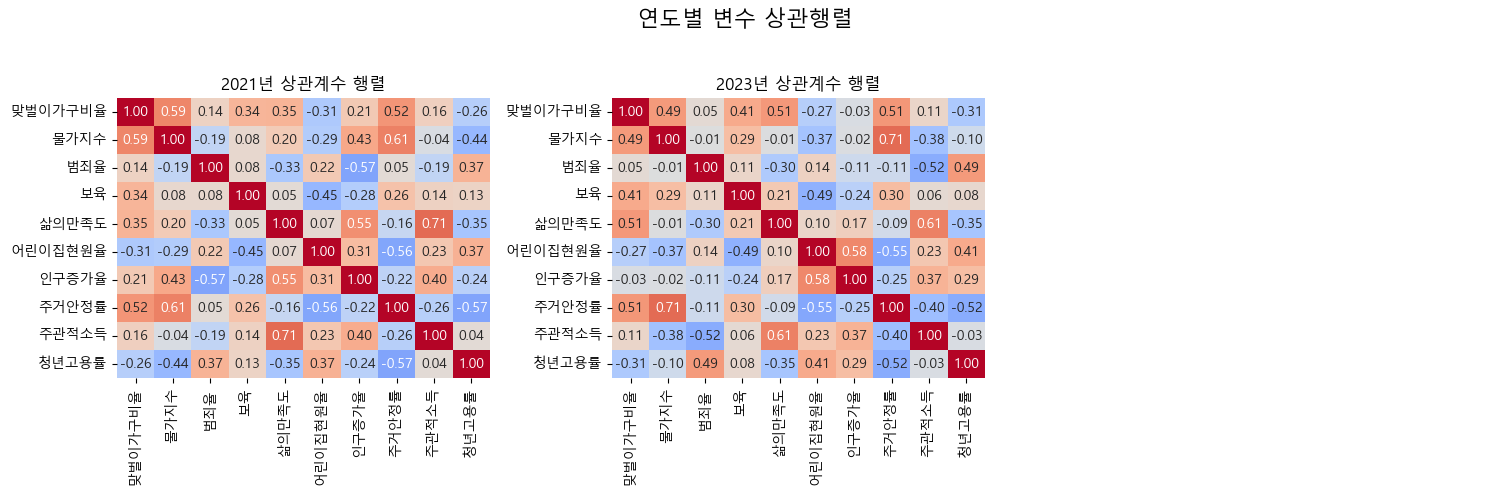

In [45]:
# 1. 연도 목록 추출
years = sorted(df_pivoted.columns.levels[0])

n_cols = 3
n_rows = (len(years) + n_cols - 1) // n_cols

# 2. subplot 준비
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))
axes = axes.flatten()

# 3. 연도별 상관행렬 히트맵
for i, year in enumerate(years):
    ax = axes[i]
    
    try:
        # 해당 연도 데이터 추출
        df_year = df_pivoted[year]
        
        # 상관계수 계산
        corr = df_year.corr()
        
        # 히트맵
        sns.heatmap(
            corr,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            ax=ax,
            cbar=False
        )
        
        ax.set_title(f'{year}년 상관계수 행렬')
        
    except Exception as e:
        ax.set_title(f'{year}년 오류')
        print(f'{year}년 처리 중 오류: {e}')
        ax.axis('off')

# 4. 빈 subplot 제거
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# 5. 전체 제목
plt.suptitle('연도별 변수 상관행렬', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [46]:
!pip install scikit-learn

In [47]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LinearRegression

PCA 분석 연도: 2023


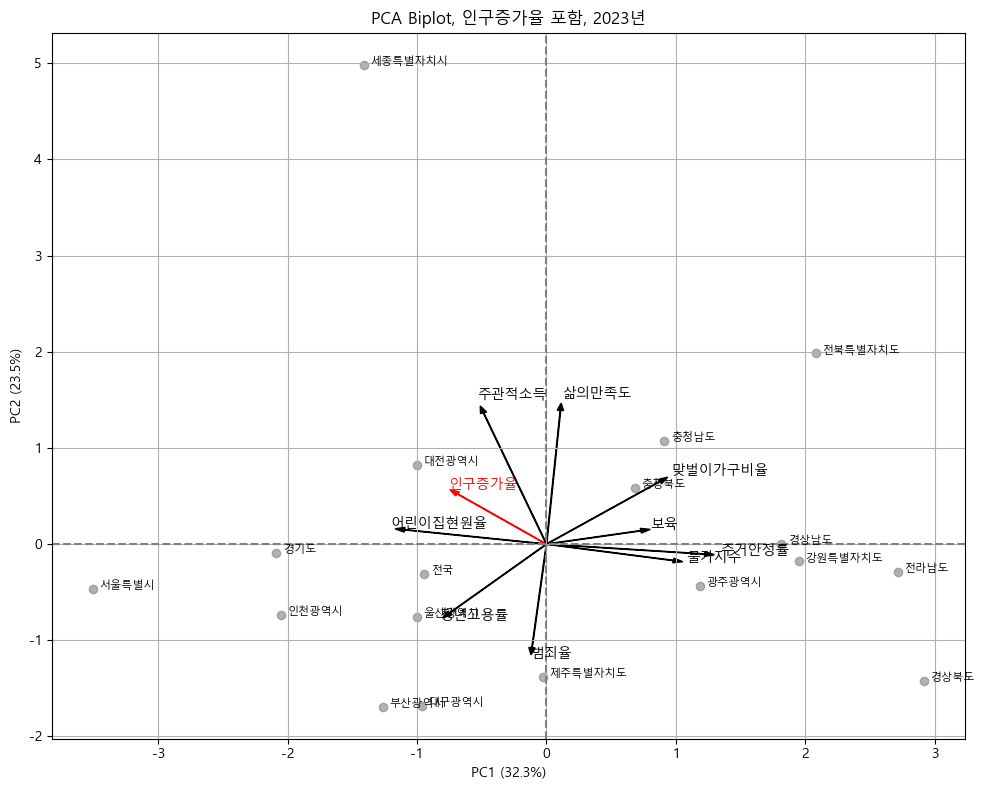

In [48]:
# 1. 변수 선택
variables = [
    '인구증가율',
    '보육',
    '주거안정률',
    '삶의만족도',
    '주관적소득',
    '맞벌이가구비율',
    '물가지수',
    '범죄율',
    '청년고용률',
    '어린이집현원율'
]

# 2. 분석 연도 선택, 공통 연도 중 가장 최신 연도
year = max(years)

print("PCA 분석 연도:", year)

# 3. 해당 연도 데이터 준비
df_year = df_pivoted[year].dropna()

X = df_year[variables]

# 4. 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 6. 변수 방향 벡터
vectors = pca.components_.T

# 7. Biplot 시각화
plt.figure(figsize=(10, 8))

# 지역 점 표시
for i, name in enumerate(X.index):
    plt.scatter(X_pca[i, 0], X_pca[i, 1], color='gray', alpha=0.6)
    plt.text(X_pca[i, 0] + 0.05, X_pca[i, 1], name, fontsize=8)

# 변수 벡터 표시
scaled_factor = 2.5

for i, var in enumerate(variables):
    color = 'red' if var == '인구증가율' else 'black'
    
    plt.arrow(
        0, 0,
        vectors[i, 0] * scaled_factor,
        vectors[i, 1] * scaled_factor,
        color=color,
        width=0.005,
        head_width=0.05
    )
    
    plt.text(
        vectors[i, 0] * scaled_factor * 1.1,
        vectors[i, 1] * scaled_factor * 1.1,
        var,
        color=color,
        fontsize=10
    )

# 꾸미기
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
plt.title(f"PCA Biplot, 인구증가율 포함, {year}년")
plt.grid(True)
plt.tight_layout()
plt.show()


In [49]:
# 1. PCA 로딩 벡터 정리
loadings = pd.DataFrame(
    pca.components_.T,
    index=variables,
    columns=['PC1', 'PC2']
)

# 2. cosine similarity 계산
target = '인구증가율'
cos_sims = {}

for var in variables:
    if var != target:
        cos_sim = cosine_similarity(
            [loadings.loc[target]],
            [loadings.loc[var]]
        )[0][0]
        cos_sims[var] = cos_sim

# 3. 결과 정리
cosine_df = pd.Series(cos_sims).sort_values(ascending=False).round(3)

print("인구증가율과 각 변수 벡터 간 cosine similarity:")
print(cosine_df)

인구증가율과 각 변수 벡터 간 cosine similarity:
어린이집현원율    0.871
주관적소득      0.837
삶의만족도      0.542
청년고용률      0.157
맞벌이가구비율   -0.278
범죄율       -0.519
보육        -0.668
주거안정률     -0.844
물가지수      -0.888
dtype: float64


# 기타 데이터

- 맞벌이 가구: 맞벌이가구.xlsx
- 물가지수: 물가지수.xlsx
- 범죄율: 범죄율.xlsx
- 청년 고용률: 청년고용률.xlsx
- 어린이집 현황: 어린이집현황.xlsx

# PCR 기반 회귀 분석

In [50]:
# 1. 독립변수와 종속변수 설정
x_variables = [
    '보육',
    '주거안정률',
    '삶의만족도',
    '주관적소득',
    '맞벌이가구비율',
    '물가지수',
    '범죄율',
    '청년고용률',
    '어린이집현원율'
]

year = max(years)
print("PCR 분석 연도:", year)

df_year = df_pivoted[year].dropna()

X = df_year[x_variables]
y = df_year['인구증가율']

# 2. X 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. PCA 적용
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 4. 누적 분산으로 주성분 수 결정, 80% 이상
explained_ratio = np.cumsum(pca.explained_variance_ratio_)
n_components = np.argmax(explained_ratio >= 0.8) + 1

print(f"선택된 주성분 개수: {n_components}")
print("누적 설명분산:", explained_ratio)

# 5. 회귀분석
X_pca_reduced = X_pca[:, :n_components]

model = LinearRegression()
model.fit(X_pca_reduced, y)

# 6. 예측값과 설명력
y_pred = model.predict(X_pca_reduced)
r_squared = model.score(X_pca_reduced, y)

print(f"R² 설명력: {r_squared:.3f}")


PCR 분석 연도: 2023
선택된 주성분 개수: 4
누적 설명분산: [0.34099487 0.59385946 0.74998213 0.85313141 0.92436829 0.95521802
 0.9833037  0.99436544 1.        ]
R² 설명력: 0.302


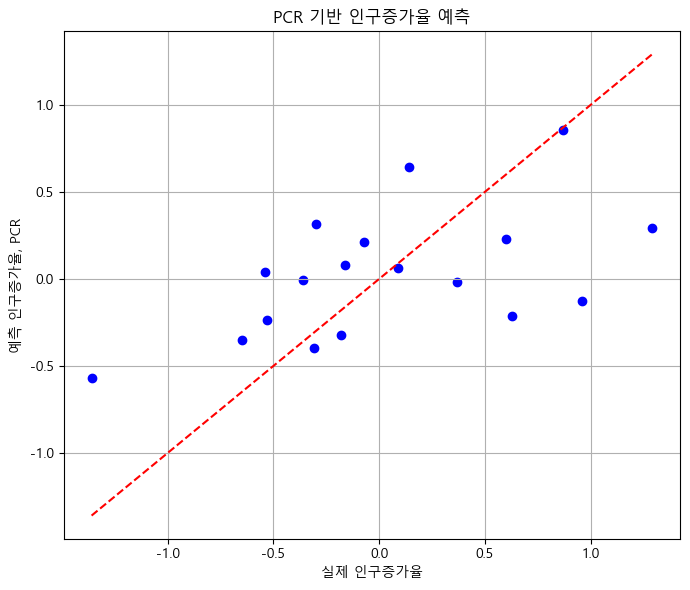

원래 변수 기준 PCR 회귀계수:
어린이집현원율    0.2002
삶의만족도      0.1167
맞벌이가구비율    0.0817
범죄율        0.0545
주관적소득      0.0484
청년고용률      0.0239
물가지수      -0.0006
주거안정률     -0.0598
보육        -0.1155
Name: β, 원 변수 기준, dtype: float64


In [51]:
plt.figure(figsize=(7, 6))

plt.scatter(y, y_pred, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')

plt.xlabel('실제 인구증가율')
plt.ylabel('예측 인구증가율, PCR')
plt.title('PCR 기반 인구증가율 예측')
plt.grid(True)
plt.tight_layout()
plt.show()# 1. 회귀계수 변환, 주성분 기준에서 원래 변수 기준으로 환산
V = pca.components_[:n_components, :].T
beta_pcr = model.coef_
beta_orig = V @ beta_pcr

# 2. 정리 및 출력
coef_series = pd.Series(
    beta_orig,
    index=x_variables,
    name='β, 원 변수 기준'
).sort_values(ascending=False).round(4)

print("원래 변수 기준 PCR 회귀계수:")
print(coef_series)

In [52]:
# 회귀계수 변환, 주성분 기준에서 원래 변수 기준으로 환산
V = pca.components_[:n_components, :].T
beta_pcr = model.coef_
beta_orig = V @ beta_pcr

# 정리 및 출력
coef_series = pd.Series(
    beta_orig,
    index=x_variables,
    name='β, 원 변수 기준'
).sort_values(ascending=False).round(4)

print("원래 변수 기준 PCR 회귀계수:")
print(coef_series)

원래 변수 기준 PCR 회귀계수:
어린이집현원율    0.2002
삶의만족도      0.1167
맞벌이가구비율    0.0817
범죄율        0.0545
주관적소득      0.0484
청년고용률      0.0239
물가지수      -0.0006
주거안정률     -0.0598
보육        -0.1155
Name: β, 원 변수 기준, dtype: float64


In [53]:
# 기타 데이터 정리를 위한 공통 함수

def find_region_col(df):
    region_candidates = [
        col for col in df.columns
        if ('행정구역' in str(col)) or ('시도' in str(col)) or ('지역' in str(col))
    ]
    if len(region_candidates) == 0:
        raise ValueError("지역 컬럼을 찾지 못했습니다.")
    return region_candidates[0]


def find_cols_by_keywords(df, keywords):
    result = []
    for col in df.columns:
        text = str(col)
        if all(keyword in text for keyword in keywords):
            result.append(col)
    return result


def make_region_year_df(df, value_cols):
    region_col = find_region_col(df)

    temp = df[[region_col] + value_cols].copy()
    temp.columns = ['지역'] + [
        clean_year(col[0]) if isinstance(col, tuple) else clean_year(col)
        for col in value_cols
    ]

    temp['지역'] = temp['지역'].astype(str).str.strip()

    for col in temp.columns[1:]:
        temp[col] = pd.to_numeric(temp[col], errors='coerce')

    return temp

In [54]:
# 맞벌이 가구
factor_dual = pd.read_excel("맞벌이가구.xlsx", engine="openpyxl", header=[0, 1])

dual_cols = find_cols_by_keywords(factor_dual, ['맞벌이가구비율'])

print("맞벌이가구비율 컬럼:", dual_cols)

df_dual = make_region_year_df(factor_dual, dual_cols)

df_dual.head(len(df_dual))

맞벌이가구비율 컬럼: [('2015', '- 맞벌이가구비율 (%)'), ('2016', '- 맞벌이가구비율 (%)'), ('2017', '- 맞벌이가구비율 (%)'), ('2018', '- 맞벌이가구비율 (%)'), ('2019', '- 맞벌이가구비율 (%)'), ('2020', '- 맞벌이가구비율 (%)'), ('2021', '- 맞벌이가구비율 (%)'), ('2022', '- 맞벌이가구비율 (%)'), ('2023', '- 맞벌이가구비율 (%)'), ('2024', '- 맞벌이가구비율 (%)')]


,지역,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,전국,44.2,45.3,44.3,46.0,45.5,45.0,45.9,46.1,48.2,48.0
1,서울특별시,38.9,40.8,39.9,40.1,39.1,39.8,40.6,41.2,43.6,43.7
2,부산광역시,38.1,38.1,37.3,39.9,38.9,37.5,39.1,38.6,42.3,43.3
3,대구광역시,42.1,44.1,40.7,42.3,41.9,41.5,42.5,41.2,43.2,42.3
4,인천광역시,41.5,42.5,43.8,45.3,44.2,42.0,43.5,44.7,46.8,47.2
5,광주광역시,46.4,43.6,45.3,48.0,48.3,48.1,46.1,45.0,48.9,48.7
6,대전광역시,42.6,43.7,43.3,47.4,47.2,46.8,46.6,45.0,49.1,47.2
7,울산광역시,38.1,38.1,36.6,38.2,37.5,37.5,38.8,40.7,42.0,40.3
8,세종특별자치시,NaN,NaN,50.1,52.0,49.9,50.4,49.4,55.8,54.8,57.1
9,경기도,41.6,43.1,42.1,44.4,43.8,43.0,44.4,45.1,47.0,46.7


In [55]:
# 물가지수
factor_price = pd.read_excel("물가지수.xlsx", engine="openpyxl", header=0)

factor_price['도시별'] = factor_price['도시별'].ffill()

df_price = factor_price[
    factor_price['지출목적별'].astype(str).str.contains('총지수', na=False)
].copy()

df_price['지역'] = factor_price['도시별'].apply(normalize_region)

year_cols = [col for col in df_price.columns if str(col).isdigit()]

df_price = df_price[['지역'] + year_cols].copy()

for col in year_cols:
    df_price[col] = pd.to_numeric(df_price[col], errors='coerce')

df_price.head(len(df_price))


,지역,2020,2021,2022,2023,2024,2025
0,전국,100,102.50,107.72,111.59,114.18,116.61
13,서울특별시,100,102.10,106.69,110.88,113.50,115.79
26,부산광역시,100,102.46,107.35,111.33,114.12,116.62
39,대구광역시,100,102.64,108.02,111.79,114.20,116.55
52,인천광역시,100,102.62,107.96,111.92,114.79,117.18
65,광주광역시,100,102.57,107.79,111.76,114.57,116.79
78,대전광역시,100,102.50,107.52,111.24,113.88,116.14
91,울산광역시,100,102.49,107.57,111.43,113.97,116.37
104,세종특별자치시,100,102.71,108.23,111.46,114.10,116.79
117,경기도,100,102.57,107.72,111.55,114.13,116.65


In [56]:
# 범죄율
factor_crime = pd.read_excel("범죄율.xlsx", engine="openpyxl", header=[0, 1])

crime_cols = find_cols_by_keywords(factor_crime, ['범죄발생건수'])

crime_cols_per = [
    col for col in crime_cols
    if ('천명당' in str(col)) or ('천 명당' in str(col))
]

if len(crime_cols_per) > 0:
    crime_cols = crime_cols_per

print("범죄율 컬럼:", crime_cols)

df_crime = make_region_year_df(factor_crime, crime_cols)

df_crime.head(len(df_crime))

범죄율 컬럼: [('2014', '인구 천명당 범죄발생건수(A÷B×1,000) (건)'), ('2015', '인구 천명당 범죄발생건수(A÷B×1,000) (건)'), ('2016', '인구 천명당 범죄발생건수(A÷B×1,000) (건)'), ('2017', '인구 천명당 범죄발생건수(A÷B×1,000) (건)'), ('2018', '인구 천명당 범죄발생건수(A÷B×1,000) (건)'), ('2019', '인구 천명당 범죄발생건수(A÷B×1,000) (건)'), ('2020', '인구 천명당 범죄발생건수(A÷B×1,000) (건)'), ('2021', '인구 천명당 범죄발생건수(A÷B×1,000) (건)'), ('2022', '인구 천명당 범죄발생건수(A÷B×1,000) (건)'), ('2023', '인구 천명당 범죄발생건수(A÷B×1,000) (건)'), ('2024', '인구 천명당 범죄발생건수(A÷B×1,000) (건)')]


,지역,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,전국,34.4,35.6,35.2,31.6,29.8,30.3,29.8,26.8,27.9,28.6,30.9
1,서울특별시,35.2,35.6,34.6,32.5,31.6,31.8,30.6,27.1,29.6,29.5,32.4
2,부산광역시,38.0,40.0,36.9,33.6,32.1,33.1,33.5,30.0,31.7,32.3,34.4
3,대구광역시,38.4,39.8,34.7,30.3,29.4,31.1,29.9,28.5,28.3,28.1,29.9
4,인천광역시,32.5,34.1,34.1,31.0,29.2,30.6,30.0,26.0,27.8,29.3,30.6
5,광주광역시,43.9,41.6,36.9,32.9,29.9,30.4,30.0,27.3,27.2,29.6,32.4
6,대전광역시,31.1,32.7,32.4,31.3,30.6,30.6,30.5,27.5,30.2,30.0,32.8
7,울산광역시,35.3,38.0,33.9,30.0,28.4,28.6,27.6,25.9,24.6,27.1,28.1
8,세종특별자치시,NaN,NaN,NaN,NaN,NaN,17.9,17.6,16.0,17.1,19.7,22.3
9,경기도,32.7,34.4,37.5,32.4,29.7,29.8,29.4,26.3,26.8,27.7,30.3


In [57]:
# 청년고용률
factor_youth = pd.read_excel("청년고용률.xlsx", engine="openpyxl", header=0)

year_cols = [col for col in factor_youth.columns if str(col).isdigit()]

df_youth = factor_youth[['시도별'] + year_cols].copy()
df_youth.columns = ['지역'] + [str(col) for col in year_cols]
df_youth['지역'] = df_youth['지역'].apply(normalize_region)

for col in df_youth.columns[1:]:
    df_youth[col] = pd.to_numeric(df_youth[col], errors='coerce')

df_youth.head(len(df_youth))


,지역,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,전국,41.2,41.7,42.1,42.7,43.5,42.2,44.2,46.6,46.5,46.1,45.0
1,서울특별시,43.8,44.6,45.3,46.1,47.5,46.6,50.5,51.5,51.8,51.2,49.1
2,부산광역시,38.8,40.3,41.2,40.4,42.9,40.5,41.2,42.0,43.9,46.1,44.1
3,대구광역시,39.3,38.3,35.2,36.3,39.8,37.8,42.6,41.3,42.3,37.5,39.4
4,인천광역시,42.2,44.4,45.1,47.9,48.8,46.8,46.9,50.6,49.2,47.4,44.8
5,광주광역시,35.3,34.1,36.3,39.4,39.6,39.6,37.3,38.8,38.9,38.1,37.2
6,대전광역시,38.9,41.1,40.2,38.1,40.6,44.7,45.0,48.0,44.4,43.4,45.0
7,울산광역시,38.3,38.7,40.9,40.4,39.1,37.6,36.5,40.5,40.3,40.2,42.3
8,세종특별자치시,NaN,NaN,37.5,38.1,35.1,36.6,35.1,33.9,33.1,36.2,33.6
9,경기도,43.9,44.0,44.8,45.3,45.4,43.1,45.5,50.0,49.9,49.5,46.6


In [58]:
# 어린이집 현황
factor_child = pd.read_excel("어린이집현황.xlsx", engine="openpyxl", header=0)

factor_child['지역'] = factor_child['시도별'].ffill().apply(normalize_region)

year_cols = [col for col in factor_child.columns if str(col).isdigit()]

capacity_df = factor_child[factor_child['항목'] == '정원'][['지역'] + year_cols].copy()
current_df = factor_child[factor_child['항목'] == '현원'][['지역'] + year_cols].copy()

capacity_df = capacity_df.set_index('지역')
current_df = current_df.set_index('지역')

for col in year_cols:
    capacity_df[col] = pd.to_numeric(capacity_df[col], errors='coerce')
    current_df[col] = pd.to_numeric(current_df[col], errors='coerce')

df_childcare = (current_df / capacity_df * 100).reset_index()

df_childcare.head(len(df_childcare))


,지역,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,전국,81.125528,82.118339,82.559520,81.725012,80.923994,76.424895,76.065428,74.183002,72.198096,70.241932,69.084972
1,서울특별시,86.857062,87.536219,87.604252,86.244713,85.426930,79.824943,77.613903,74.868532,73.492293,70.743679,69.487897
2,부산광역시,82.212767,83.657900,84.199236,83.410034,82.004090,77.718789,76.775745,73.345941,71.106609,70.338945,70.079979
3,대구광역시,76.661895,78.009435,78.439274,78.542069,78.744776,73.477003,74.383903,71.486018,69.354610,67.059652,65.438398
4,인천광역시,85.874281,85.985114,86.115310,84.317485,83.047536,77.391423,77.362536,76.888845,76.102582,74.982754,75.055973
5,광주광역시,76.458540,75.497377,73.858869,72.207588,71.905949,66.779353,69.741303,68.195397,66.271112,64.805831,63.190800
6,대전광역시,80.328930,81.597388,81.509835,81.436551,80.391461,75.369796,73.929952,71.896794,71.504016,70.325587,68.790126
7,울산광역시,84.784469,86.350200,85.986850,86.318745,84.022699,79.499080,79.021485,78.409878,75.437301,73.097954,70.667641
8,세종특별자치시,79.932191,86.168269,85.823441,80.839034,80.440415,78.583862,78.206904,79.445420,75.801953,71.863594,71.522133
9,경기도,82.044335,83.614101,84.734990,84.132755,83.763235,78.763752,79.225076,78.128587,75.760241,74.436414,73.403837


In [59]:
data_sources = {
    '인구증가율': df_pop,
    '보육': df_facility,
    '주거안정률': df_housing,
    '삶의만족도': df_satisfaction,
    '주관적소득': df_income,
    '맞벌이가구비율': df_dual,
    '물가지수': df_price,
    '범죄율': df_crime,
    '청년고용률': df_youth,
    '어린이집현원율': df_childcare
}
